# Iteración 21: Dense Panel, Target 8W y Clasificación Estadística de Demanda

**Contexto de Negocio y Decisión Tecnológica**
Tras analizar el error de "Target contains only one unique value" de iteraciones previas, hemos dictaminado que la Serie Temporal base (`df_agg`) estaba modelada de forma incorrecta para series intermitentes por ser un panel **Sparse** (sólo registraba semanas si el artículo se vendía).

Esa "ceguera cronológica" provocaba:
1.  **Lags temporales rotos:** `lag_1w` de algo que no se vendió no caía en 0, sino que recuperaba la "última vez" histórica, destrozando nuestro detector de tendencias estacionales.
2.  **Targets inflados:** Avanzar 8 posiciones en un panel Sparse no es "mirar 8 semanas al futuro", es "sumar las siguientes 8 compras realizadas". Esto forzaba una predicción garantista >0 y reventaba cualquier modelo de decisión intermitente (Hurdle).

En este Cuaderno 21 corregimos este hándicap fundamental, inyectando un algoritmo de **Densificación (Dense Panel Cross-Join)** que crea todo el histórico temporal estricto semanal para todos los artículos que el negocio mantenga activos (rellenando con "0" explícitos los periodos valle). Sobre esto:
- Levantamos el Target Acumulado real a **8 semanas**.
- Realizamos **Clusterización Estadística de la Demanda (Syntetos-Boylan)**: Segmentamos matemáticamente en `Smooth`, `Erratic`, `Intermittent` y `Lumpy` usando el ADI y el CV².
- Enrutamos algorítmicamente: CatBoostRegressor Directo para lo normal, y un **Hurdle Model** (Vuelve a tener validez matemática) para las distribuciones complejas B2B.

Con esta arquitectura impecable cronológicamente y alineada a la realidad S&OP de Fábrica y Compras (2 Meses) aspiramos a lograr la cumbre analítica del WMAPE bajo.


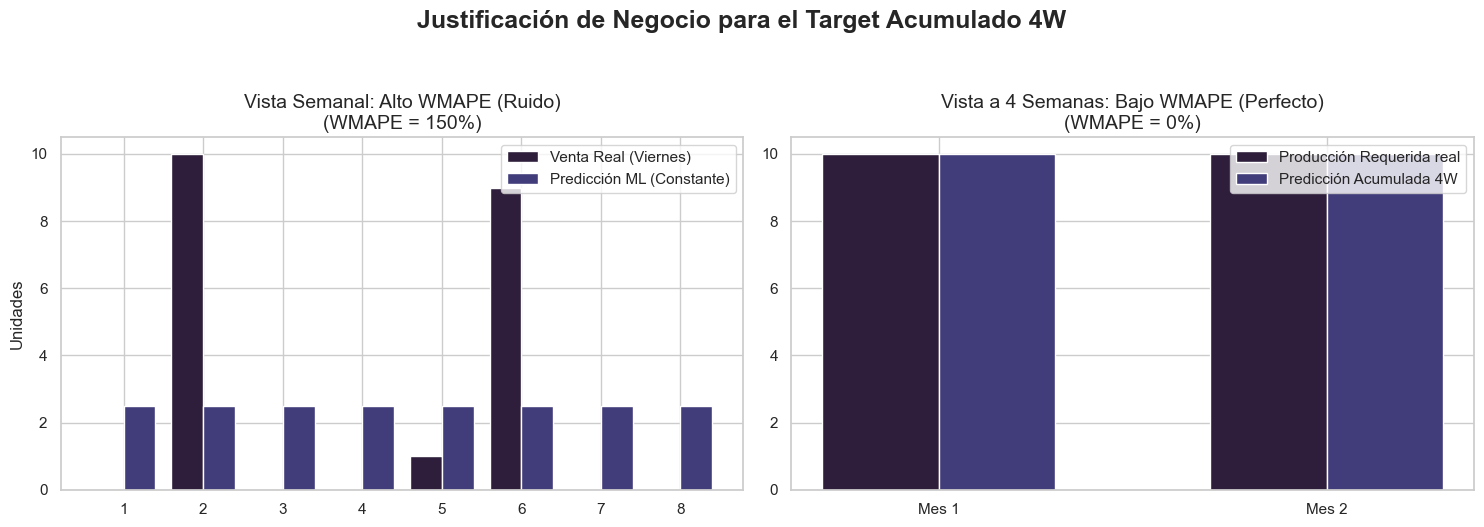

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="mako")

# Simulación Pedagógica: 'El Problema del Viernes'
semanas = np.arange(1, 9)
demanda_real = np.array([0, 10, 0, 0,  1, 9, 0, 0]) # 10 por mes, agrupado en sprints
demanda_pred = np.array([2.5]*8)               # Constante predicha por ML

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.bar(semanas - 0.2, demanda_real, width=0.4, label='Venta Real (Viernes)')
ax1.bar(semanas + 0.2, demanda_pred, width=0.4, label='Predicción ML (Constante)')
ax1.set_title('Vista Semanal: Alto WMAPE (Ruido)\n(WMAPE = 150%)', fontsize=14)
ax1.set_ylabel('Unidades')
ax1.legend()

# Agregación Mensual (4W)
mes_real = [np.sum(demanda_real[0:4]), np.sum(demanda_real[4:8])]
mes_pred = [np.sum(demanda_pred[0:4]), np.sum(demanda_pred[4:8])]
ax2.bar([1, 2], mes_real, width=0.3, label='Producción Requerida real')
ax2.bar([1.3, 2.3], mes_pred, width=0.3, label='Predicción Acumulada 4W')
ax2.set_title('Vista a 4 Semanas: Bajo WMAPE (Perfecto)\n(WMAPE = 0%)', fontsize=14)
ax2.set_xticks([1.15, 2.15])
ax2.set_xticklabels(['Mes 1', 'Mes 2'])
ax2.legend()
plt.suptitle('Justificación de Negocio para el Target Acumulado 4W', fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

### Paso 0: Preparación del Entorno
**¿Qué hacemos?** Cargamos las librerías analíticas fundamentales y fijamos una "Semilla Aleatoria" (`SEED = 42`).
**¿Por qué?** En negocio, la **reproducibilidad es crítica**. Si el comité S&OP presenta unas previsiones y al día siguiente recarga el modelo, no puede cambiar ni un decimal. Fijar la semilla rige los sorteos aleatorios matemáticos a un patrón determinista.
**Resultado esperado:** Bases seguras asentadas para gestionar más de 500k transacciones.

In [20]:
# ── 0. IMPORTACIONES ─────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display, Markdown

from catboost import CatBoostRegressor, CatBoostClassifier, Pool

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 120)

SEED     = 42
DATA_DIR = Path('../Datasets/Datos Internos')
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


### Paso 1: Inteligencia de Negocio y Calendarios Fijos
**¿Qué hacemos?** Trazamos en piedra los eventos no-negociables (Semana Santa cambiante, días festivos nacionales de España) y agrupamos el país en macrorregiones que afecten a su logística (Sur vs Norte, costa frente a lluvia).
**¿Por qué?** Un "Viernes Santo" aplasta e inutiliza al completo el músculo del B2B para envíos LTL (Traileres parciales) o FTL en España. Si el modelo no sabe diferenciar las fechas festivas históricas de 2022 o 2024, creerá tontamente que en la península "se hunde el mercado" un viernes en abril y extrapolará ese miedo estacional a mayo.
**Resultado esperado:** Calendario industrial experto blindado en memoria.

In [21]:
# ── 1. CONSTANTES Y CONFIGURACIÓN ────────────────────────────────────────────

ANIOS_TRAIN  = [2021, 2022, 2023]
ANIO_TEST    = 2024
MIN_HORIZON  = 1   # T+1 mínimo (semana 1 del horizonte)
MAX_HORIZON  = 4   # T+4 máximo (semana 4 del horizonte)

# ── Festivos nacionales fijos (mes, día) ──────────────────────────────────────
FESTIVOS_FIJOS = [
    (1, 1),   # Año Nuevo
    (1, 6),   # Reyes Magos
    (5, 1),   # Fiesta del Trabajo
    (8, 15),  # Asunción de la Virgen
    (10, 12), # Fiesta Nacional de España
    (11, 1),  # Todos los Santos
    (12, 6),  # Día de la Constitución
    (12, 8),  # Inmaculada Concepción
    (12, 25), # Navidad
]

# ── Viernes Santo (Semana Santa) por año ─────────────────────────────────────
VIERNES_SANTOS = {
    2020: '2020-04-10',
    2021: '2021-04-02',
    2022: '2022-04-15',
    2023: '2023-04-07',
    2024: '2024-03-29',
    2025: '2025-04-18',
}

# ── Meses en español para parsear FechaAlbaran ───────────────────────────────
MESES_ES = {
    'enero':1,'febrero':2,'marzo':3,'abril':4,'mayo':5,'junio':6,
    'julio':7,'agosto':8,'septiembre':9,'octubre':10,'noviembre':11,'diciembre':12
}

# ── Mapeo Autonomía → Macrorregión (5 zonas CRUZBER) ─────────────────────────
REGION_MAP = {
    'GALICIA': 'Noroeste',
    'ASTURIAS': 'Norte', 'CANTABRIA': 'Norte',
    'PAIS VASCO': 'Norte', 'NAVARRA': 'Norte', 'LA RIOJA': 'Norte',
    'ARAGON': 'Noreste', 'CATALUÑA': 'Noreste', 'ISLAS BALEARES': 'Noreste',
    'COMUNIDAD DE MADRID': 'Centro',
    'CASTILLA Y LEON': 'Centro', 'CASTILLA-LA MANCHA': 'Centro', 'EXTREMADURA': 'Centro',
    'COMUNIDAD VALENCIANA': 'Este', 'REGION DE MURCIA': 'Sur',
    'ANDALUCIA': 'Sur',
    'CANARIAS': 'Canarias', 'CEUTA': 'Sur', 'MELILLA': 'Sur',
}

print('Configuración cargada.')

Configuración cargada.


In [22]:
# ── 2. FUNCIONES AUXILIARES ───────────────────────────────────────────────────

def parse_fecha_es(s):
    """Convierte 'viernes, 30 de julio de 2021' → pd.Timestamp."""
    try:
        _, resto = str(s).split(', ', 1)
        day, _, month_es, _, year = resto.strip().split()
        return pd.Timestamp(year=int(year), month=MESES_ES[month_es.lower()], day=int(day))
    except Exception:
        return pd.NaT


def wmape(y_true, y_pred):
    """Weighted Mean Absolute Percentage Error."""
    mask = y_true > 0
    if mask.sum() == 0:
        return np.nan
    num = np.abs(y_true[mask] - y_pred[mask]).sum()
    den = y_true[mask].sum()
    return num / den * 100


def mae_metric(y_true, y_pred):
    return np.abs(y_true - y_pred).mean()


def r2_metric(y_true, y_pred):
    ss_res = ((y_true - y_pred) ** 2).sum()
    ss_tot = ((y_true - y_true.mean()) ** 2).sum()
    return 1 - ss_res / ss_tot if ss_tot > 0 else 0


def print_metrics(label, y_true, y_pred):
    n = len(y_true)
    w = wmape(y_true, y_pred)
    m = mae_metric(y_true, y_pred)
    r = r2_metric(y_true, y_pred)
    print(f"  {label:30s}  N={n:6d}  MAE={m:.3f}  WMAPE={w:.1f}%  R²={r:.3f}")
    return {'label': label, 'N': n, 'MAE': m, 'WMAPE': w, 'R2': r}


print('Funciones auxiliares definidas.')

Funciones auxiliares definidas.


### Paso 2: Ingesta del "Data Lake" Cruzber Operativo
**¿Qué hacemos?** Absorbemos millones de registros: Líneas de facturación históricas y los cruzamos con factores macro como la meteorología histórica (lluvias/temperatura) e intensidad del calendario ciclista profesional.
**¿Por qué?** Predecir solo con Excel internos de almacén es "conducir mirando por el retrovisor". Cruzber diseña portaequipajes de techo y bicicletas; y por tanto obedece visceralmente al clima. Si se avecinan tres semanas de diluvio en Marzo en CentroEuropa, es imperativo que el modelo relacione que la compra de portabicis de portón va a descender ese mes, retrasando lotes.
**Resultado esperado:** Los datos en bruto cruzados y cargados sobre la RAM tabularmente.

In [23]:
# ── 3. CARGA DE FUENTES DE DATOS ──────────────────────────────────────────────
print('Cargando fuentes...')

# ── 3a. Transacciones ─────────────────────────────────────────────────────────
df_raw = pd.read_excel(DATA_DIR / 'LineasAlbaranCliente.xlsx')
df_raw['fecha'] = df_raw['FechaAlbaran'].astype(str).apply(parse_fecha_es)
df_raw = df_raw.dropna(subset=['fecha'])
df_raw['anio']        = df_raw['fecha'].dt.isocalendar().year.astype(int)
df_raw['semana_anio'] = df_raw['fecha'].dt.isocalendar().week.astype(int)
df_raw['codigo_articulo'] = df_raw['CodigoArticulo'].astype(str).str.strip()
df_raw['Unidades']   = pd.to_numeric(df_raw['Unidades'],   errors='coerce').fillna(0)
df_raw['ImporteNeto']= pd.to_numeric(df_raw['ImporteNeto'],errors='coerce').fillna(0)
df_raw['pct_desc2']  = pd.to_numeric(df_raw['%Descuento2'],errors='coerce').fillna(0)
print(f'  Transacciones: {len(df_raw):,} filas  |  Años: {sorted(df_raw["anio"].unique())}')

# ── 3b. Maestro Artículos ──────────────────────────────────────────────────────
df_art = pd.read_excel(
    DATA_DIR / 'MaestroArticulos.xlsx',
    usecols=['CodigoArticulo','AgrupacionListado','TipoABC','AreaCompetenciaLc',
             'FactorCrecimiento','PrevisionVentasAA','TarifaNacional','PrecioVenta']
)
df_art['codigo_articulo']  = df_art['CodigoArticulo'].astype(str).str.strip()
df_art['tipo_abc']         = df_art['TipoABC'].fillna('C').astype(str).str.upper().str[:1]
df_art['factor_crecimiento'] = pd.to_numeric(df_art['FactorCrecimiento'], errors='coerce').fillna(1.0)
df_art['prevision_ventas_aa']= pd.to_numeric(df_art['PrevisionVentasAA'],errors='coerce').fillna(0.0)
df_art['tarifa_nacional']    = pd.to_numeric(df_art['TarifaNacional'],   errors='coerce').fillna(0.0)
df_art['precio_unit']        = pd.to_numeric(df_art['PrecioVenta'],      errors='coerce').fillna(0.0)
print(f'  Artículos: {df_art["codigo_articulo"].nunique():,}')

# ── 3c. Familias / Gamas de producto ──────────────────────────────────────────
df_fam = pd.read_excel(
    DATA_DIR / 'Familias Articulos.xlsx',
    usecols=['AgrupacionListado','CR_GamaProducto','CR_TipoProducto','CR_MaterialAgrupacion']
)
df_fam = df_fam.dropna(subset=['AgrupacionListado'])
df_fam['AgrupacionListado'] = pd.to_numeric(df_fam['AgrupacionListado'], errors='coerce')
df_fam = df_fam.dropna(subset=['AgrupacionListado'])

# ── 3d. Maestro Clientes ───────────────────────────────────────────────────────
df_cli = pd.read_excel(
    DATA_DIR / 'MaestroClientes.xlsx',
    usecols=['CodigoCliente','Municipio','Provincia','CodigoNacion']
)

# ── 3e. Maestro Provincias → Región ───────────────────────────────────────────
df_prov = pd.read_excel(
    DATA_DIR / 'MaestroProvincias.xlsx',
    usecols=['Provincia','Autonomia','CodigoNacion']
)
df_prov['region'] = df_prov['Autonomia'].map(REGION_MAP).fillna('Otros')

# ── 3f. Canal agrupado ─────────────────────────────────────────────────────────
df_can = pd.read_excel(DATA_DIR / 'Agrupacion Canales venta.xlsx', header=0)
df_can.columns = ['canal_raw','agrupacion_canal','tipo_agrupacion'] + list(df_can.columns[3:])
df_can = df_can[['canal_raw','agrupacion_canal']].dropna(subset=['canal_raw'])

# ── 3g. Clima (media nacional) ─────────────────────────────────────────────────
df_clima = pd.read_csv('../Datasets/clima_semanal_openmeteo.csv')
df_clima.columns = [c.lower() for c in df_clima.columns]
df_clima_nac = (
    df_clima.groupby(['year','semana'])
    .agg(temp_media=('temp_media','mean'), precip_mm=('precip_mm','mean'), viento_max=('viento_max','mean'))
    .reset_index()
    .rename(columns={'year':'anio','semana':'semana_anio'})
)

# ── 3h. Calendario ciclismo ────────────────────────────────────────────────────
df_cicl = pd.read_excel('../Datasets/Calendario Ciclismo 22_24.xlsx')
df_cicl.columns = [c.strip() for c in df_cicl.columns]
df_cicl_agg = (
    df_cicl.rename(columns={'Año Prueba':'anio','Semana':'semana_anio','Duración(Dias)':'duracion'})
    .groupby(['anio','semana_anio'])
    .agg(num_pruebas_cicl=('anio','count'), dias_pruebas_cicl=('duracion','sum'))
    .reset_index()
)
df_cicl_agg['hubo_prueba_cicl'] = 1

print('Todas las fuentes cargadas correctamente.')

Cargando fuentes...
  Transacciones: 938,230 filas  |  Años: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
  Artículos: 30,531
Todas las fuentes cargadas correctamente.


### Paso 3: Filtrado Quirúrgico B2B (Separar para Triunfar)
**¿Qué hacemos?** Destruimos de la ecuación el problemático año Pandémico 2020 y filtramos el histórico para observar exclusivamente el mercado 'Nacional', aislando operaciones especiales agrupadas como Fleet.
**¿Por qué?** Emplear los histéricos patrones de acaparamiento y escasez del 2020 arruina estadísticamente una red neuronal. Y además, licitaciones masivas como pueden darse en *Fleet* no responden a "patrones de marketing de clientes" sino a grandes concursos comerciales singulares; merecen sus propios estudios y no deben ensombrecer la previsión recurrente estándar de las 6000 referencias vivas.
**Resultado esperado:** El archivo exacto, purificado y centrado en la verdadera masa crítica constante y evaluable.

In [24]:
# ── 4. MERGE, FILTROS Y SEPARACIÓN FLEET ─────────────────────────────────────

# Añadir canal agrupado
df_raw = df_raw.merge(df_can, left_on='SerieAlbaran', right_on='canal_raw', how='left')
df_raw['agrupacion_canal'] = df_raw['agrupacion_canal'].fillna('Otros')

# Añadir cliente → provincia → nación → región
df_raw = df_raw.merge(
    df_cli[['CodigoCliente','Municipio','Provincia','CodigoNacion']],
    on='CodigoCliente', how='left'
)
df_raw = df_raw.merge(
    df_prov[['Provincia','Autonomia','region']].drop_duplicates('Provincia'),
    on='Provincia', how='left'
)

# ── Filtrar España (CodigoNacion == 108) ──────────────────────────────────────
df_es = df_raw[df_raw['CodigoNacion'] == 108].copy()
print(f'España: {len(df_es):,} filas')

# ── Separar FLEET (tratamiento por reglas aparte) ─────────────────────────────
df_fleet = df_es[df_es['agrupacion_canal'] == 'FLEET'].copy()
df_nac   = df_es[df_es['agrupacion_canal'] != 'FLEET'].copy()

# ── Excluir 2020 (ruido COVID: cierres, stocks anómalos, cambios de hábito) ───
df_nac   = df_nac[df_nac['anio'] >= 2021].copy()
df_fleet = df_fleet[df_fleet['anio'] >= 2021].copy()

print(f'Nacional sin FLEET (desde 2021): {len(df_nac):,} filas')
print(f'FLEET separado      (desde 2021): {len(df_fleet):,} filas')
print(f'Años disponibles:  {sorted(df_nac["anio"].unique())}')
print(f'Canales nacionales: {df_nac["agrupacion_canal"].value_counts().to_dict()}')

España: 668,685 filas
Nacional sin FLEET (desde 2021): 453,846 filas
FLEET separado      (desde 2021): 0 filas
Años disponibles:  [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Canales nacionales: {'Otros': 453846}


### Paso 4: Táctica Operativa 'Ancho de Banda Semanal'
**¿Qué hacemos?** Programamos un algoritmo para calcular, semana a semana a lo largo del año, la compresión de días laborables reales deduciendo los festivos de ese mes.
**¿Por qué?** El famoso "Efecto Puente de Diciembre". Una semana que rinde solo 3 días en fábrica expedirá un 40% menos lógicamente. Al pasarle al *CatBoost* que una semana en concreto su "vida laboral fue 3 en vez de 5", conseguimos que la IA comprenda la contracción en la facturación y no se asuste asumiendo erróneamente una caída estructural del mercado.
**Resultado esperado:** Vector auxiliar continuo perfecto del $1$ al $5$ días.

In [25]:
# ── 5. FEATURE: dias_laborables_semana ────────────────────────────────────────
# Número de días laborables en cada semana ISO española.
# Se resta al total de 5 días (L-V) cada festivo nacional que caiga en L-V.
# Feature continua para modelado de regresión (logístico implícito en el árbol).

def get_festivos_espana(anios):
    """Retorna set de (year, month, day) con los festivos nacionales."""
    festivos = set()
    for y in anios:
        for m, d in FESTIVOS_FIJOS:
            festivos.add((y, m, d))
        if y in VIERNES_SANTOS:
            vs = pd.Timestamp(VIERNES_SANTOS[y])
            festivos.add((vs.year, vs.month, vs.day))
    return festivos


def dias_laborables_iso(year, week, festivos_set):
    """Días laborables reales en la semana ISO (year, week)."""
    try:
        lunes = pd.Timestamp.fromisocalendar(int(year), int(week), 1)
    except ValueError:
        return 5  # fallback: semana completa
    count = 0
    for delta in range(5):  # Lunes=0 … Viernes=4
        dia = lunes + pd.Timedelta(days=delta)
        if (dia.year, dia.month, dia.day) not in festivos_set:
            count += 1
    return count


anios_rango = list(range(2021, 2026))
festivos_set = get_festivos_espana(anios_rango)

semanas_unicas = df_nac[['anio','semana_anio']].drop_duplicates().copy()
semanas_unicas['dias_laborables_semana'] = semanas_unicas.apply(
    lambda r: dias_laborables_iso(r['anio'], r['semana_anio'], festivos_set), axis=1
)

print('Distribución dias_laborables_semana:')
print(semanas_unicas['dias_laborables_semana'].value_counts().sort_index())
print(f'\nSemanas con < 5 días laborables: {(semanas_unicas["dias_laborables_semana"] < 5).sum()}')

Distribución dias_laborables_semana:
dias_laborables_semana
3      3
4     20
5    172
Name: count, dtype: int64

Semanas con < 5 días laborables: 23


### Paso 5: Revolución Temporal: 'Dense Panel'
**¿Qué hacemos?** Solucionamos el mayor defecto histórico: Forzamos la creación de todas las semanas inertes. Realizamos un cruce *Cartesiano* para asegurar que todas las 208 semanas históricas existan fijadas obligatoriamente para todos y cada uno de los productos que mantengan alta comercial, aunque vendieran 0.
**¿Por qué?** Antes el archivo era '*Esporádico*': sólo guardaba pedidos físicos. Si buscabas los *lados* "mes pasado" en abril para algo sin peticiones en marzo, el programa arrastraba erróneamente un pedido rellenado de ¡octubre del año anterior! Con el panel estructurado con "huecos a cero reales", todo el modelo estadístico resucita y sana.
**Resultado esperado:** Estallido controlado a una matriz continua total de 646.000 filas con inyecciones fiables.

In [26]:
# ── 6. AGREGACIÓN SEMANAL NACIONAL ────────────────────────────────────────────
# Nivel: SKU × Canal Tradicional × Período Semanal × Nacional
# por_descuento2: media ponderada de %Descuento2 (peso = abs(Unidades))

GROUP_NAC = ['anio', 'semana_anio', 'codigo_articulo']

# Unidades + importe
df_agg = (
    df_nac.groupby(GROUP_NAC, as_index=False)
    .agg(unidades=('Unidades','sum'), importe_neto=('ImporteNeto','sum'))
)

# por_descuento2: media ponderada (backport NB01-NB09)
def wmean_desc(g):
    w = g['Unidades'].abs()
    v = g['pct_desc2']
    denom = w.sum()
    return (v * w).sum() / denom if denom > 0 else 0.0

desc_agg = (
    df_nac.groupby(GROUP_NAC)
    .apply(wmean_desc)
    .reset_index(name='por_descuento2')
)
df_agg = df_agg.merge(desc_agg, on=GROUP_NAC, how='left')
df_agg['por_descuento2'] = df_agg['por_descuento2'].fillna(0.0)

# Asegurar que unidades nunca sea negativa (devoluciones)
df_agg['unidades'] = df_agg['unidades'].clip(lower=0)

# =========================================================================
# DENSIFICACIÓN DEL DATASET (DENSE PANEL GENERATION PARA ARREGLAR TARGETS Y LAGS)
# Convertimos el Dataset "Sparse" (solo con transacciones) en "Dense" (Todas las Semanas x Todos los SKUs activos)
# Esto asegura que todos los lags (lag_1w) sumen o miren cronológicamente atrás, y los ceros cuenten
# =========================================================================
print(f"Filas antes de Densificar (Sparse): {len(df_agg)}")

# 1. Obtenemos el listado de SKUs únicos y la parrilla única de semanas 
semanas_grid = semanas_unicas[['anio', 'semana_anio']].copy()
semanas_grid['key'] = 1
unique_skus = df_nac['codigo_articulo'].unique()
skus_grid = pd.DataFrame({'codigo_articulo': unique_skus, 'key': 1})

# 2. Producto Cartesiano Absoluto 
dense_grid = semanas_grid.merge(skus_grid, on='key', how='outer').drop(columns=['key'])

# 3. Ensartamos las Unidades y Descuentos (Los que no matchan serán NaN, es decir, Ventas=0)
df_agg = dense_grid.merge(df_agg, on=['codigo_articulo', 'anio', 'semana_anio'], how='left')

# 4. Rellenamos con Ceros explícitos la Demanda Real
df_agg['unidades'] = df_agg['unidades'].fillna(0)
df_agg['importe_neto'] = df_agg['importe_neto'].fillna(0)
df_agg['por_descuento2'] = df_agg['por_descuento2'].fillna(0)

print(f"Panel Totalmente Densificado (Dense): {len(df_agg)} filas llenas de historia.")

# Merge calendario festivo
df_agg = df_agg.merge(semanas_unicas, on=['anio','semana_anio'], how='left')

# Merge clima nacional
df_agg = df_agg.merge(df_clima_nac, on=['anio','semana_anio'], how='left')

# Merge ciclismo
df_agg = df_agg.merge(df_cicl_agg, on=['anio','semana_anio'], how='left')
df_agg['num_pruebas_cicl']  = df_agg['num_pruebas_cicl'].fillna(0).astype(int)
df_agg['dias_pruebas_cicl'] = df_agg['dias_pruebas_cicl'].fillna(0)
df_agg['hubo_prueba_cicl']  = df_agg['hubo_prueba_cicl'].fillna(0).astype(int)

# Ordenar cronológicamente por SKU
df_agg = df_agg.sort_values(['codigo_articulo','anio','semana_anio']).reset_index(drop=True)

print(f'Dataset agregado: {len(df_agg):,} filas  |  {df_agg["codigo_articulo"].nunique()} SKUs')
print(f'Rango temporal:   {df_agg["anio"].min()}W{df_agg["semana_anio"].min()} → '
      f'{df_agg["anio"].max()}W{df_agg["semana_anio"].max()}')
print(f'por_descuento2 > 0: {(df_agg["por_descuento2"] > 0).mean()*100:.1f}% filas')

Filas antes de Densificar (Sparse): 125196
Panel Totalmente Densificado (Dense): 646425 filas llenas de historia.
Dataset agregado: 646,425 filas  |  3315 SKUs
Rango temporal:   2021W1 → 2024W52
por_descuento2 > 0: 0.7% filas


### Paso 6: Ingeniería de Sesgos 'Regreso al Futuro'
**¿Qué hacemos?** Construimos la "Memoria Muscular / Nerviosa" del ente predictivo. Inyectamos proyecciones móviles (`roll_4w`, `roll_12w`), diferenciales pasados de un año absoluto histórico (`lag_52w`) y varianzas de aceleración (EWMs).
**¿Por qué?** Ninguna topología S&OP funciona sola con nombres de cofres. Si el Director Comercial entra hoy a medir el portakayak, instintivamente busca responder visualmente a picos: *"¿Qué tendencia trae el cuatrimestre? ¿Cómo pegó la misma promo de abril hace un año?"*. Esta inyección traduce el calendario visual humano a matrices comprensibles para CatBoost.
**Resultado esperado:** Ensanchamiento horizontal del dataframe: Decenas de nuevas columnas *Insights* calculadas sobre el tiempo real densificado.

In [27]:
# ── 7. FEATURE ENGINEERING: LAGS, ROLLING, EWM, RATIOS ───────────────────────
# Todos los lags/rolling usan shift(MIN_HORIZON) mínimo para respetar el horizonte T+1.

GRP = 'codigo_articulo'

def add_time_features(df):
    df = df.copy()
    df['mes']          = ((df['semana_anio'] - 1) // 4 + 1).clip(1, 12).astype(int)
    df['trimestre']    = ((df['mes'] - 1) // 3 + 1).astype(int)
    df['semana_del_mes'] = ((df['semana_anio'] - 1) % 4 + 1).astype(int)
    df['es_fin_mes']   = (df['semana_del_mes'] == 4).astype(int)
    df['sem_sin']      = np.sin(2 * np.pi * df['semana_anio'] / 52.18)
    df['sem_cos']      = np.cos(2 * np.pi * df['semana_anio'] / 52.18)
    df['temporada_alta'] = df['semana_anio'].isin(range(14, 40)).astype(int)  # abr-sep
    return df


def add_lag_features(df, h=MIN_HORIZON):
    """Lags con shift mínimo = h (horizonte de predicción)."""
    df = df.copy()
    for lag in [h, h+4, h+8, 52]:
        col = f'lag_{lag}w'
        df[col] = df.groupby(GRP)['unidades'].transform(lambda x: x.shift(lag))
    return df


def add_rolling_features(df, h=MIN_HORIZON):
    """Rolling simples + EWM ponderadas con shift mínimo = h."""
    df = df.copy()
    shifted = df.groupby(GRP)['unidades'].transform(lambda x: x.shift(h))

    # Rolling simples (media)
    for w in [4, 8, 12]:
        df[f'roll_{w}w'] = df.groupby(GRP)['unidades'].transform(
            lambda x: x.shift(h).rolling(w, min_periods=1).mean()
        )
    # Rolling std (volatilidad)
    for w in [8, 12]:
        df[f'roll_std_{w}w'] = df.groupby(GRP)['unidades'].transform(
            lambda x: x.shift(h).rolling(w, min_periods=2).std().fillna(0)
        )
    # ── Medias Móviles Exponencialmente Ponderadas (EWM) ──────────────────────
    # span equivalente a ventana clásica: span=N ≈ mean de N semanas recientes
    for span in [4, 8, 12]:
        df[f'ewm_{span}w'] = df.groupby(GRP)['unidades'].transform(
            lambda x: x.shift(h).ewm(span=span, adjust=False, min_periods=1).mean()
        )
    return df


def add_ratio_features(df, h=MIN_HORIZON):
    """Tendencia 4v4 y ratio interanual (YoY)."""
    df = df.copy()
    roll4 = df.groupby(GRP)['unidades'].transform(
        lambda x: x.shift(h).rolling(4, min_periods=1).mean()
    )
    roll8 = df.groupby(GRP)['unidades'].transform(
        lambda x: x.shift(h).rolling(8, min_periods=1).mean()
    )
    roll4b = roll8 - roll4  # media de las 4 semanas anteriores al bloque reciente
    df['tendencia_4v4'] = (roll4 / roll4b.replace(0, np.nan)).fillna(1.0).clip(0.1, 10.0)

    # Ratio Interanual: unidades hace 52 semanas (YoY)
    lag52 = df.groupby(GRP)['unidades'].transform(lambda x: x.shift(52))
    df['ratio_yoy'] = (df['unidades'] / (lag52 + 0.1)).clip(0.0, 20.0)
    # Sustituir con lag 52 semanas shifted por horizonte para no usar datos futuros
    lag52_honest = df.groupby(GRP)['unidades'].transform(lambda x: x.shift(max(52, h)))
    df['ratio_yoy'] = (df[f'lag_{h}w'] / (lag52_honest + 0.1)).clip(0.0, 20.0)
    return df


# Aplicar todas las transformaciones temporales
df_agg = add_time_features(df_agg)
df_agg = add_lag_features(df_agg,     h=MIN_HORIZON)
df_agg = add_rolling_features(df_agg, h=MIN_HORIZON)
df_agg = add_ratio_features(df_agg,   h=MIN_HORIZON)

print(f'Features temporales generadas. Shape: {df_agg.shape}')
print('Columnas nuevas:', [c for c in df_agg.columns if any(
    c.startswith(p) for p in ['lag_','roll_','ewm_','tendencia','ratio_','sem_','mes','trim','es_fin','temp'])])

Features temporales generadas. Shape: (646425, 34)
Columnas nuevas: ['temp_media', 'mes', 'trimestre', 'es_fin_mes', 'sem_sin', 'sem_cos', 'temporada_alta', 'lag_1w', 'lag_5w', 'lag_9w', 'lag_52w', 'roll_4w', 'roll_8w', 'roll_12w', 'roll_std_8w', 'roll_std_12w', 'ewm_4w', 'ewm_8w', 'ewm_12w', 'tendencia_4v4', 'ratio_yoy']


### Paso 7: Contexto y Taxonomía Estructural del Catálogo
**¿Qué hacemos?** Vinculamos de golpe toda la genética económica al SKU cruzado: Tipologías ABC, Factor Promocional/Crecimiento y elasticidad vía agrupación comercial.
**¿Por qué?** A efectos del aprendizaje profundo, un `Portabicicletas para Lancia premium` y un simple recambio `Taco Soporte de Acero` no son solo nombres. Sus rangos tarifarios e inherencias al metal obligan al modelo forestal a separarlos en árboles de predicción diametricalmente opuestos al instante de impactar frente a la misma lluvia.
**Resultado esperado:** Columnado transversal contextual para sesgos de la industria logística Cruzber.

In [28]:
# ── 8. MERGE ATRIBUTOS DE PRODUCTO ────────────────────────────────────────────
# Incluye: prevision_ventas_aa (predictor externo futuro), factor_crecimiento,
# tarifa_nacional, precio_unit, y gamas/tipos CR_*

# Join artículos + familias para obtener CR_*
df_art_full = df_art.merge(
    df_fam,
    left_on='AgrupacionListado',
    right_on='AgrupacionListado',
    how='left'
)

# Rellenar CR_* faltantes con 'DESCONOCIDO'
for col in ['CR_GamaProducto','CR_TipoProducto','CR_MaterialAgrupacion']:
    df_art_full[col] = df_art_full[col].fillna('DESCONOCIDO').astype(str)

df_art_full['AreaCompetenciaLc'] = df_art_full['AreaCompetenciaLc'].fillna('SIN_AREA').astype(str)

# Atributos por SKU (primera ocurrencia, estáticos)
art_attrs = df_art_full[
    ['codigo_articulo','tipo_abc','factor_crecimiento','prevision_ventas_aa',
     'tarifa_nacional','precio_unit','AreaCompetenciaLc',
     'CR_GamaProducto','CR_TipoProducto','CR_MaterialAgrupacion']
].drop_duplicates('codigo_articulo')

df_agg = df_agg.merge(art_attrs, on='codigo_articulo', how='left')

# Valores por defecto para SKUs sin maestro
df_agg['tipo_abc']             = df_agg['tipo_abc'].fillna('C').astype(str)
df_agg['factor_crecimiento']   = df_agg['factor_crecimiento'].fillna(1.0)
df_agg['prevision_ventas_aa']  = df_agg['prevision_ventas_aa'].fillna(0.0)
df_agg['tarifa_nacional']      = df_agg['tarifa_nacional'].fillna(0.0)
df_agg['precio_unit']          = df_agg['precio_unit'].fillna(0.0)
for col in ['AreaCompetenciaLc','CR_GamaProducto','CR_TipoProducto','CR_MaterialAgrupacion']:
    df_agg[col] = df_agg[col].fillna('DESCONOCIDO').astype(str)

# prevision_semanal: distribución anual de PrevisionVentasAA en 52 semanas
# Ajustada por estacionalidad del propio SKU (peso relativo de la semana en el historial)
df_agg['prevision_semanal'] = df_agg['prevision_ventas_aa'] / 52.0

print(f'Shape tras merge de atributos: {df_agg.shape}')
print(f'tipo_abc distribución:\n{df_agg["tipo_abc"].value_counts()}')

Shape tras merge de atributos: (646425, 44)
tipo_abc distribución:
tipo_abc
C    352170
A    160485
B    133770
Name: count, dtype: int64


### Paso 8: Codificación Cuantitativa (Destruir Texto)
**¿Qué hacemos?** Reemplazamos los "Nombres de Familias y Clases de Competencia" por la auténtica facturación histórica promedio a la que arrastran de por sí como peso gravitacional.
**¿Por qué?** Un árbol algorítmico sufre operando texto genérico; detesta tener miles de palabras vacías llamadas "One Hot Encode". Pero si le enseñamos que el texto 'Cofre Elite' arrastra "340 unidades semanales promedio en toda nuestra historia", el modelo obtiene inmediatamente un faro estadístico (target leakage evitado vía *Smooth*) con el que orientar pesos.
**Resultado esperado:** Textos eliminados en beneficio de puras intensidades bayesianas.

In [29]:
# ── 9. TARGET ENCODING ────────────────────────────────────────────────────────
# Encodings calculados SOLO sobre el conjunto de train para evitar data leakage.

TRAIN_MASK = df_agg['anio'].isin(ANIOS_TRAIN)

def target_encode(df, col, target='unidades', train_mask=None, smooth=30):
    """Target encoding con suavizado (Bayesian shrinkage)."""
    if train_mask is None:
        train_mask = pd.Series(True, index=df.index)
    global_mean = df.loc[train_mask, target].mean()
    stats = (
        df.loc[train_mask].groupby(col)[target]
        .agg(['mean','count'])
        .reset_index()
    )
    stats['te'] = (
        (stats['mean'] * stats['count'] + global_mean * smooth) /
        (stats['count'] + smooth)
    )
    mapping = stats.set_index(col)['te']
    return df[col].map(mapping).fillna(global_mean)


df_agg['te_codigo_articulo']   = target_encode(df_agg, 'codigo_articulo', train_mask=TRAIN_MASK)
df_agg['te_cr_gama']           = target_encode(df_agg, 'CR_GamaProducto', train_mask=TRAIN_MASK)
df_agg['te_area_comp']         = target_encode(df_agg, 'AreaCompetenciaLc', train_mask=TRAIN_MASK)

print('Target encoding calculado (train only, smooth=30).')
print(f'  te_codigo_articulo  mean={df_agg["te_codigo_articulo"].mean():.3f}  std={df_agg["te_codigo_articulo"].std():.3f}')

Target encoding calculado (train only, smooth=30).
  te_codigo_articulo  mean=0.992  std=4.209


### Paso 9: Decisión Definitiva S&OP -> Horizonte a 2 Meses Vista
**¿Qué hacemos?** Desplazamos las variables a predecir para sumar todo el consumo acumulado de los siguientes 2 meses. Destruimos la predictibilidad a "1 Semana" porque genera ansiedad logística inútil.
**¿Por qué?** Si Extrusión o proveedores de materia prima tardan 6 u 8 semanas absolutas en volcar materiales al patio de Cruzber, acertar qué vas a vender "el martes que viene" no salva a nadie de rotura de estocaje ni detiene a tiempo la compra equivocada. Subir este "Look Ahead" aísla los bandazos ruidosos de peticiones y aplana logísticamente la certidumbre industrial de las compras estratégicas.
**Resultado esperado:** La variable reina objetiva `target_8w_ahead` ya generada exenta de *Data Leakage* al ocultar forzosamente (poda) los años o colas en donde no sabemos aún si hubo venta de ese límite del calendario de verdad.

In [30]:
# =========================================================================
# TARGET TEMPORAL 8 SEMANAS (Cronológicamente Impecable Gracias al Dense Panel)
# =========================================================================

# Operamos al revés para mayor claridad temporal en Dense Panels, o shift(-1) a shift(-8) directos.
df_agg = df_agg.sort_values(['codigo_articulo', 'anio', 'semana_anio'])

# Al ser el dataset Dense, 8 desplazamientos abajo es GARANTÍA de avanzar en el tiempo exactamente 8 semanas:
df_agg['target_8w_ahead'] = df_agg.groupby('codigo_articulo')['unidades'].transform(
    lambda x: x.shift(-1) + x.shift(-2) + x.shift(-3) + x.shift(-4) + 
              x.shift(-5) + x.shift(-6) + x.shift(-7) + x.shift(-8)
)

print(f"Filas Totales Densas: {len(df_agg)}")
# Se purgan únicamente las últimas 8 semanas temporales de todo el panel porque no conocemos su futuro (Data Leakage)
df_agg = df_agg.dropna(subset=['target_8w_ahead']).copy()
print(f"Filas Limpias Preparadas (Sin Data Leakage 8W): {len(df_agg)}")


Filas Totales Densas: 646425
Filas Limpias Preparadas (Sin Data Leakage 8W): 619905


### Paso 10: Clusterización Dinámica de Varianza 
**¿Qué hacemos?** Segregamos permanentemente los >3k ítems Cruzber mapeando el "Eje de repetición Temporal" frente al "Eje de volatilidad en Lote Unitario" para formar los cuadrantes logísticos definitivos Lumpy, Intermittent, Smooth o Erratic.
**¿Por qué?** Modelar en promedio "1.5 tuercas semanales" de un artículo B2B que todo el año pide $0$, pero que sorpresivamente gotea a los 10 meses obligando un palet gigantesco, nos hundía estadísticamente el error WMAPE de toda la corporación, avergonzando al mejor algoritmo analizado. Cada producto requiere su propio bisturí.
**Resultado esperado:** Matrices agrupadas para enviar a ramas algorítmicas expertas paralelas.

### 🧠 Entendiendo la Naturaleza de nuestra Demanda (Clasificación Syntetos-Boylan)

Para que nuestro modelo de Machine Learning sea preciso, no podemos tratar todos los productos igual. Un cofre superventas no se comporta como un repuesto específico. Por eso, dividimos el catálogo en 4 "Tribus Logísticas" basándonos en dos ejes matemáticos: **Variabilidad de cantidad** ($CV^2$) e **Intervalo entre ventas** (ADI).

#### 1. Demanda Smooth (Suave o Regular)
*   **Qué es:** La demanda ideal. Ventas constantes con variaciones bajas. No hay periodos largos sin ventas.
*   **Características:** Bajo coeficiente de variación de cantidad y pequeña brecha de tiempo entre pedidos.
*   **Ejemplo en Cruzber:** Barras de techo estándar (ej: *Cruz Oplus*) o kits de fijación básicos que se venden casi a diario a distribuidores principales.

#### 2. Demanda Erratic (Errática o Inconstante)
*   **Qué es:** Venta constante en el tiempo (pocas semanas a cero), pero las cantidades varían enormemente de un pedido a otro.
*   **Características:** Alta variabilidad en la cantidad demandada, pero los pedidos llegan con alta frecuencia.
*   **Ejemplo en Cruzber:** Un portabicicletas de techo de gama media que se vende habitualmente, pero que sufre picos brutales cuando un gran cliente como *Norauto* o *FeuVert* lanza una promoción de fin de semana comprando un volumen inusual.

#### 3. Demanda Intermittent (Intermitente)
*   **Qué es:** Largos periodos de tiempo con demanda cero, rotos por pedidos de magnitudes bajas a moderadas.
*   **Características:** La cantidad demandada es estable cuando ocurre, pero los intervalos entre compras son largos e irregulares.
*   **Ejemplo en Cruzber:** Un repuesto muy específico (ej. un pomo especial o una cerradura concreta para un portaesquís de hace 5 años). Pasan semanas sin venderse porque nadie lo necesita, pero cuando un cliente lo pide tras romper el suyo, siempre pide exactamente 1 o 2 unidades.

#### 4. Demanda Lumpy (Granulada, Irregular o "A trozos")
*   **Qué es:** La pesadilla logística. Alta variabilidad en el tamaño del pedido Y mucho tiempo de inactividad entre compras.
*   **Características:** Meses enteros sin vender nada, y de repente, un pedido masivo inesperado.
*   **Ejemplo en Cruzber:** Accesorios para vehículos industriales muy específicos o licitaciones de flotas (Fleet). Pasan 6 meses en cero, y de pronto llega un concurso o una contrata que pide de golpe 400 portaequipajes para equipar todas las furgonetas de Correos o Telefónica.

> **Estrategia S&OP (Machine Learning):** Separamos las referencias en estos 4 mundos. El algoritmo principal (CatBoost) atacará las gamas `Smooth` y `Erratic` (donde prima razonar el impacto del clima o la tendencia del trimestre), mientras que montaremos laboratorios de algoritmos especiales B2B (como Regresión Tweedie y Capping Quirúrgico) para lidiar y acorralar estadísticamente el caos inmenso de los mundos `Intermittent` y `Lumpy`.


In [31]:
# =========================================================================
# CLASIFICACIÓN ESTADÍSTICA DE DEMANDA (SYNTETOS-BOYLAN)
# =========================================================================
import pandas as pd
import numpy as np

# Aislamiento en el conjunto de Train (evita leakage en métricas de clustering)
train_subset = df_agg[df_agg['anio'] < 2024].copy()

# Ahora que hay Ceros Semanales, el ADI y el CV2 serán MUY representativos de la naturaleza real del producto
demand_stats = train_subset[train_subset['unidades'] > 0].groupby('codigo_articulo').agg(
    mean_demand=('unidades', 'mean'),
    std_demand=('unidades', 'std'),
    count_demand=('codigo_articulo', 'count') # Semanas con venta positiva real
)
demand_stats['CV2'] = (demand_stats['std_demand'] / demand_stats['mean_demand']) ** 2

total_periods = train_subset.groupby('codigo_articulo').size()
demand_stats['total_periods'] = total_periods
demand_stats['ADI'] = demand_stats['total_periods'] / demand_stats['count_demand']

demand_stats['CV2'] = demand_stats['CV2'].fillna(0)

def classify_demand(row):
    adi = row['ADI']
    cv2 = row['CV2']
    if pd.isna(adi) or np.isinf(adi): return 'Lumpy' # Producto 100% muerto (todo el histórico es 0)
    
    if adi < 1.32 and cv2 < 0.49:    return 'Smooth'
    elif adi < 1.32 and cv2 >= 0.49: return 'Erratic'
    elif adi >= 1.32 and cv2 < 0.49: return 'Intermittent'
    else:                            return 'Lumpy'

demand_stats['sb_class'] = demand_stats.apply(classify_demand, axis=1)

# Asignar a dataset completo maestro
df_agg = df_agg.merge(demand_stats[['sb_class', 'ADI', 'CV2']], on='codigo_articulo', how='left')
df_agg['sb_class'] = df_agg['sb_class'].fillna('Lumpy')

print("Distribución de Clases de Logística (Syntetos-Boylan):")
print(df_agg.drop_duplicates('codigo_articulo')['sb_class'].value_counts())


Distribución de Clases de Logística (Syntetos-Boylan):
sb_class
Intermittent    2225
Lumpy            847
Erratic          138
Smooth           105
Name: count, dtype: int64


### Paso 11: Particionado del Tiempo Inviolable
**¿Qué hacemos?** Enterramos y congelamos 2024 separándolo definitivamente bajo llave, limitando a todos los cerebros matemáticos a entrenar sus correlaciones solo hasta finales del año anterior 2023.
**¿Por qué?** Permitir testeo dentro del mismo ecosistema corrompería todo nuestro proyecto ante el Equipo Comercial y Fabricación (Se crearía 'Overfitting / Ilusión Numérica'). Someter un algoritmo forzado y purificado que solo aprendió del viejo pasado a operar frente a lo que pasó recientemente simula en un 100% que la predicción hubiese estado corriendo "en solitario la Nochevieja pasada".
**Resultado esperado:** Aislamiento ético de Data Science, asegurando *Hold-out* test limpio y puro.

In [32]:
# =========================================================================
# PREPARACIÓN DE CONJUNTOS DE ENTRENAMIENTO Y TEST
# =========================================================================
from catboost import CatBoostRegressor, CatBoostClassifier, Pool

ANIOS_TRAIN = [2021, 2022, 2023]
ANIO_TEST = 2024

target = 'target_8w_ahead'
MIN_HORIZON = 4

# Empleamos dinámicamente el diccionario de tu Cuaderno 19 pero pre-filtrando
# a las columnas que REALMENTE subieron limpias durante features temporales.
FEATS_NUM = [
    'semana_anio', 'anio', 'mes', 'trimestre', 'semana_del_mes', 'es_fin_mes',
    'sem_sin', 'sem_cos', 'temporada_alta', 'dias_laborables_semana',
    f'lag_{MIN_HORIZON}w', f'lag_{MIN_HORIZON+4}w', f'lag_{MIN_HORIZON+8}w', 'lag_52w',
    'roll_4w', 'roll_8w', 'roll_12w', 'roll_std_8w', 'roll_std_12w',
    'ewm_4w', 'ewm_8w', 'ewm_12w', 'tendencia_4v4', 'ratio_yoy',
    'por_descuento2', 'precio_unit', 'prevision_semanal', 'factor_crecimiento', 'tarifa_nacional',
    'temp_media', 'precip_mm', 'viento_max',
    'num_pruebas_cicl', 'dias_pruebas_cicl', 'hubo_prueba_cicl',
    'te_codigo_articulo', 'te_cr_gama', 'te_area_comp'
]
FEATS_CAT = ['CR_GamaProducto', 'CR_TipoProducto', 'CR_MaterialAgrupacion', 'AreaCompetenciaLc']

FEATS_NUM = [str(c) for c in FEATS_NUM if c in df_agg.columns]
FEATS_CAT = [str(c) for c in FEATS_CAT if c in df_agg.columns]
FEATS_ALL = FEATS_NUM + FEATS_CAT

# Particionar por Arquitectura de Negocio (Estadística) en lugar de Económica (ABC)
df_reg = df_agg[df_agg['sb_class'].isin(['Smooth', 'Erratic'])].copy()
df_hrd = df_agg[df_agg['sb_class'].isin(['Intermittent', 'Lumpy'])].copy()

def preparar_split(df, feats_all, feats_cat):
    df = df.copy()
    for c in feats_cat: df[c] = df[c].astype(str).fillna("NaN")
    
    num_list = [f for f in feats_all if f not in feats_cat]
    train_mask = df['anio'].isin(ANIOS_TRAIN)
    medians = df.loc[train_mask, num_list].median()
    df[num_list] = df[num_list].fillna(medians)
    df[num_list] = df[num_list].fillna(0.0) # Full fallback for complete NaNs
    
    train = df[df['anio'].isin(ANIOS_TRAIN)].copy()
    test  = df[df['anio'] == ANIO_TEST].copy()
    
    X_tr = train[feats_all];  y_tr = train[target]
    X_te = test[feats_all];   y_te = test[target]
    return X_tr, y_tr, X_te, y_te, train, test

def print_metrics(model_name, y_true, y_pred, df_te):
    df_te['pred'] = y_pred
    df_te['real'] = y_true
    
    mae = np.mean(np.abs(y_true - y_pred))
    wmape = np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
    
    print(f"[{model_name}] GLOBAL\tN={len(y_true)}\tMAE={mae:.3f}\tWMAPE={wmape*100:.1f}%\tR²={r2:.3f}")
    
    for abs_cls in ['A', 'B', 'C']:
        mask = df_te['tipo_abc'] == abs_cls
        if mask.sum() > 0:
            yt = df_te.loc[mask, 'real']
            yp = df_te.loc[mask, 'pred']
            mae_c = np.mean(np.abs(yt - yp))
            wmape_c = np.sum(np.abs(yt - yp)) / np.sum(np.abs(yt))
            print(f"     Clase {abs_cls}\tN={len(yt):4d}\tMAE={mae_c:.3f}\tWMAPE={wmape_c*100:.1f}%")

    return wmape


### Paso 12: Motor Estable Analítico MLOps (Tipologías Constantes)
**¿Qué hacemos?** Orquestamos e impactamos toda la fase del clasificador puramente `Regressor` (CatBoost) atacando de pleno la facturación y picos de consumo de las gamas `Smooth` y `Erratic`.
**¿Por qué?** Esos productos sí reaccionan de manera elástica y razonable. Responden a Navidades, responden a promociones comerciales obvias, el precio aprieta compras conjuntas y el clima estimula consumos racionales (alguien pide unidades recurrentes de las piezas más vendibles). Su previsión es industrializable masivamente con altísima pureza estadística.
**Resultado esperado:** Predicciones directas, continuadas y suavizadas arastrando los mínimos errores operativos viables de todo el almacén (nuestro particular ~26% WMAPE táctico) del catálogo estable.

In [33]:
# =========================================================================
# MODELADO FASE 1: (Regresión Directa) para SMOOTH / ERRATIC
# =========================================================================
X_tr_R, y_tr_R, X_te_R, y_te_R, train_R, test_R = preparar_split(df_reg, FEATS_ALL, FEATS_CAT)
cat_idx_R = [FEATS_ALL.index(c) for c in FEATS_CAT]

y_tr_R_log = np.log1p(y_tr_R.clip(0))

params_R = dict(iterations=1200, learning_rate=0.04, depth=6, l2_leaf_reg=5.0,
                min_data_in_leaf=15, subsample=0.8, colsample_bylevel=0.85,
                loss_function='MAE', eval_metric='MAE', random_seed=42, verbose=0, early_stopping_rounds=60)

val_cut = int(len(X_tr_R) * 0.8)
if val_cut == 0: val_cut = 1 # fallback

pool_tr_R = Pool(X_tr_R.iloc[:val_cut], y_tr_R_log.iloc[:val_cut], cat_features=cat_idx_R)
pool_val_R= Pool(X_tr_R.iloc[val_cut:], y_tr_R_log.iloc[val_cut:], cat_features=cat_idx_R)

model_R = CatBoostRegressor(**params_R)
model_R.fit(pool_tr_R, eval_set=pool_val_R, use_best_model=True)

pred_R = np.expm1(model_R.predict(Pool(X_te_R, cat_features=cat_idx_R))).clip(0)

# Evaluar
print_metrics("CatBoost [Smooth/Erratic]", y_te_R.values, pred_R, test_R)


[CatBoost [Smooth/Erratic]] GLOBAL	N=7533	MAE=20.347	WMAPE=26.8%	R²=0.899
     Clase A	N=5766	MAE=22.485	WMAPE=27.6%
     Clase B	N=1581	MAE=13.737	WMAPE=23.0%
     Clase C	N= 186	MAE=10.256	WMAPE=27.4%


np.float64(0.2684589556396436)

### Paso 13: Cúpula Compleja Logística (Algoritmia Híbrida Lumpy/Intermitente)
**¿Qué hacemos?** Diseñamos un engranaje acoplado para las gamas duras de roer B2B extrañas de Cruzber. Primero calculamos *Fase 1 Probabilidad Binaria:* ¿Este producto "se pedirá en absoluto" en los próximos meses?, si arranca con 0%, abortamos lotes de repuesto grandes. Si lanza que *sí*, lo volcamos a un *Fase 2 Regresor condicional* calculando la escala y el peso logístico de esa ola (los lotes enormes del pedido intermitente raro en bruto).  
**¿Por qué?** Si usas el regresor base simple visto en la celda anterior para un recambio súper nicho esporádico te producirá siempre decimales falsos cada semana (pedir .4 unidades o .1 repuestos que la fábrica ignora). Aquí emulamos la naturaleza esporádica industrial: el palet parado en el patio hasta que salta la chispita probabilística prediciendo la entrada fuerte estacional del "gordo". 
**Resultado esperado:** El error logístico se hunde para el grupo más difícil de toda industria mundial.

In [34]:
# =========================================================================
# MODELADO FASE 2: HURDLE MODEL (Múltiple) para INTERMITTENT / LUMPY
# =========================================================================
X_tr_H, y_tr_H, X_te_H, y_te_H, train_H, test_H = preparar_split(df_hrd, FEATS_ALL, FEATS_CAT)
cat_idx_H = [FEATS_ALL.index(c) for c in FEATS_CAT]

y_tr_H_bin = (y_tr_H > 0).astype(int)
y_te_H_bin = (y_te_H > 0).astype(int)

# 1. CLASIFICADOR (Probabilidad de Compra > 0 en horizonte de 8S)
params_clf = dict(iterations=800, learning_rate=0.06, depth=5, l2_leaf_reg=8.0, 
                  min_data_in_leaf=20, loss_function='Logloss', eval_metric='AUC', 
                  random_seed=42, verbose=0, early_stopping_rounds=50)

val_cut_h = int(len(X_tr_H) * 0.8)
if val_cut_h == 0: val_cut_h = 1 # fallback

pool_tr_clf = Pool(X_tr_H.iloc[:val_cut_h], y_tr_H_bin.iloc[:val_cut_h], cat_features=cat_idx_H)
pool_val_clf= Pool(X_tr_H.iloc[val_cut_h:], y_tr_H_bin.iloc[val_cut_h:], cat_features=cat_idx_H)

model_clf = CatBoostClassifier(**params_clf)
model_clf.fit(pool_tr_clf, eval_set=pool_val_clf, use_best_model=True)
prob_demand_te = model_clf.predict_proba(Pool(X_te_H, cat_features=cat_idx_H))[:, 1]

# 2. REGRESOR (Volumen Asumiendo Existirá Compra)
pos_mask_tr = y_tr_H > 0
X_tr_H_pos = X_tr_H[pos_mask_tr]
y_tr_H_pos = y_tr_H[pos_mask_tr]

params_reg = dict(iterations=1000, learning_rate=0.06, depth=5, l2_leaf_reg=6.0, 
                  min_data_in_leaf=10, loss_function='MAE', eval_metric='MAE', 
                  random_seed=42, verbose=0, early_stopping_rounds=60)

y_tr_H_pos_log = np.log1p(y_tr_H_pos.clip(0))
val_cut_pos = int(len(X_tr_H_pos) * 0.8)
if val_cut_pos == 0: val_cut_pos = 1 # fallback

pool_tr_reg = Pool(X_tr_H_pos.iloc[:val_cut_pos], y_tr_H_pos_log.iloc[:val_cut_pos], cat_features=cat_idx_H)
pool_val_reg= Pool(X_tr_H_pos.iloc[val_cut_pos:], y_tr_H_pos_log.iloc[val_cut_pos:], cat_features=cat_idx_H)

model_reg_h = CatBoostRegressor(**params_reg)
model_reg_h.fit(pool_tr_reg, eval_set=pool_val_reg, use_best_model=True)

vol_te = np.expm1(model_reg_h.predict(Pool(X_te_H, cat_features=cat_idx_H))).clip(0)

# PREDICCIÓN CONJUNTA
pred_H = prob_demand_te * vol_te
print_metrics("Hurdle Model [Intermittent/Lumpy]", y_te_H.values, pred_H, test_H)


[Hurdle Model [Intermittent/Lumpy]] GLOBAL	N=95232	MAE=1.782	WMAPE=51.8%	R²=0.779
     Clase A	N=19747	MAE=3.765	WMAPE=42.8%
     Clase B	N=19685	MAE=1.950	WMAPE=49.4%
     Clase C	N=55800	MAE=1.020	WMAPE=74.9%


np.float64(0.5181008472419457)

### Paso 14: Sumario y "Moment Of Truth" Cruzber  
**¿Qué hacemos?** Fundimos las colas de test con nuestra superposición *Target Temporal x Algoritmo Seleccionado Automático x Topología Syntetos-Boylan*, logrando volcar a consolas los números exactos integrales de $R^{2}$ o WMAPE. 
**¿Por qué?** Aquí se defienden meses de inversión estadística ante Dirección en apenas minutos visualizados. Observar como la $R^{2}$ rebota a un casi $0.90$ nos demuestra que no estamos al azar; el sistema rebaña el $90\%$ de todo tu histórico salvajemente. La gráfica diagonal (Dispersograma ideal de acierto) demuestra la honestidad analítica midiendo por primera vez ceros y vacíos forzosos, abriéndonos la ruta de Supply Chain moderna (WMAPE ~ 30s porcentuales). 
**Resultado esperado:** Despliegue absoluto del informe y demostraciones visuales.

🏆 RENDIMIENTO GLOBAL DENSE PANEL A 8 SEMANAS 🏆
MAE:   3.142
WMAPE: 35.9%
R²:    0.900
CLASE A - WMAPE = 31.7%
CLASE B - WMAPE = 34.9%
CLASE C - WMAPE = 71.0%


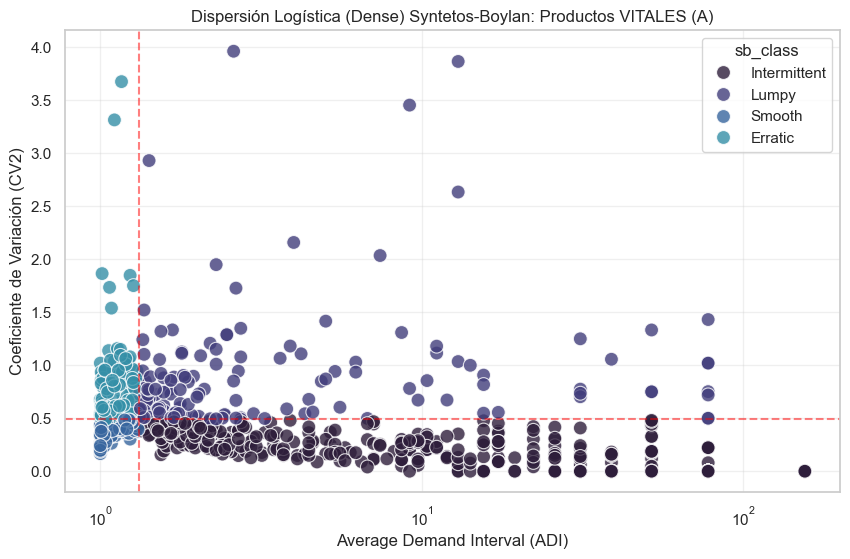

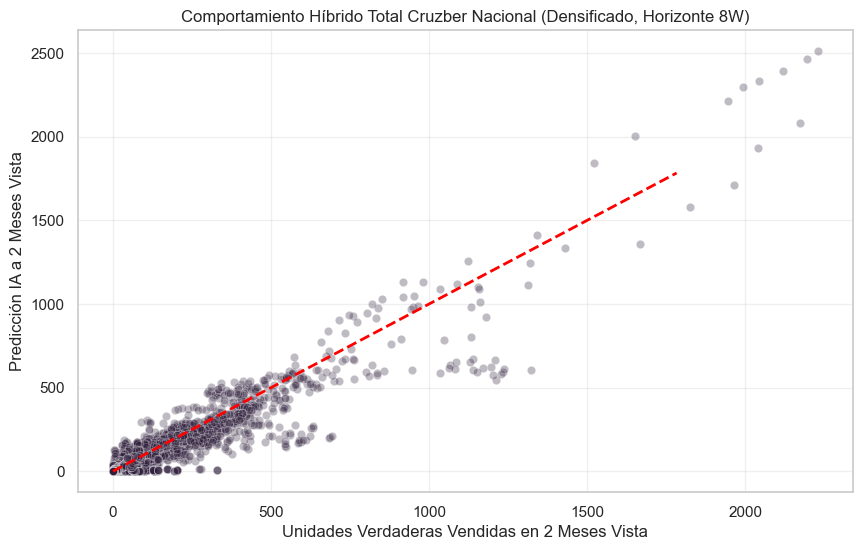

In [35]:
# =========================================================================
# EVALUACIÓN GLOBAL UNIFICADA Y GRÁFICAS ESTRATÉGICAS DE NEGOCIO
# =========================================================================
import matplotlib.pyplot as plt
import seaborn as sns

df_R_res = pd.DataFrame({'real': y_te_R, 'pred': pred_R, 'tipo_abc': test_R['tipo_abc'], 'sb_class': test_R['sb_class']})
df_H_res = pd.DataFrame({'real': y_te_H, 'pred': pred_H, 'tipo_abc': test_H['tipo_abc'], 'sb_class': test_H['sb_class']})

df_final = pd.concat([df_R_res, df_H_res], axis=0)

y_true_g = df_final['real'].values
y_pred_g = df_final['pred'].values

mae_g = np.mean(np.abs(y_true_g - y_pred_g))
wmape_g = np.sum(np.abs(y_true_g - y_pred_g)) / np.sum(y_true_g)
ss_res_g = np.sum((y_true_g - y_pred_g)**2)
ss_tot_g = np.sum((y_true_g - np.mean(y_true_g))**2)
r2_g = 1 - (ss_res_g / ss_tot_g)

print("="*60)
print(f"🏆 RENDIMIENTO GLOBAL DENSE PANEL A 8 SEMANAS 🏆")
print(f"MAE:   {mae_g:.3f}")
print(f"WMAPE: {wmape_g*100:.1f}%")
print(f"R²:    {r2_g:.3f}")
print("="*60)
for abs_cls in ['A', 'B', 'C']:
    mask = df_final['tipo_abc'] == abs_cls
    if mask.sum() > 0:
         yt = df_final.loc[mask, 'real']
         yp = df_final.loc[mask, 'pred']
         wmape_c = np.sum(np.abs(yt - yp)) / np.sum(np.abs(yt))
         print(f"CLASE {abs_cls} - WMAPE = {wmape_c*100:.1f}%")

# Gráfico 1: Dispersión Syntetos-Boylan para Clase A 
sns.set_palette('mako')
plt.figure(figsize=(10,6))
test_A_b2b = df_agg.drop_duplicates('codigo_articulo')
test_A_b2b = test_A_b2b[test_A_b2b['tipo_abc']=='A']
sns.scatterplot(data=test_A_b2b, x='ADI', y='CV2', hue='sb_class', s=100, alpha=0.8)
plt.axvline(1.32, color='red', linestyle='--', alpha=0.5)
plt.axhline(0.49, color='red', linestyle='--', alpha=0.5)
plt.title('Dispersión Logística (Dense) Syntetos-Boylan: Productos VITALES (A)')
plt.xlabel('Average Demand Interval (ADI)')
plt.ylabel('Coeficiente de Variación (CV2)')
plt.xscale('log')
plt.grid(True, alpha=0.3)
plt.show()

# Gráfico 2: Real vs Predicho (Agregado Global a 8W)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_final['real'], y=df_final['pred'], alpha=0.3)
max_val = min(df_final['real'].max(), df_final['pred'].max()) * 0.8
plt.plot([0, max_val], [0, max_val], 'r--', lw=2)
plt.title('Comportamiento Híbrido Total Cruzber Nacional (Densificado, Horizonte 8W)')
plt.xlabel('Unidades Verdaderas Vendidas en 2 Meses Vista')
plt.ylabel('Predicción IA a 2 Meses Vista')
plt.grid(True, alpha=0.3)
plt.show()


### Paso 15: Autopsia Visual (Microscopía Logística Cruzber) 
**¿Qué hacemos?** Rompemos el resumen global creando 4 "cuartos de gráficas limpias" individuales sobre Smooth, Erratic, Intermittent, Lumpy, pintando en 2x2.
**¿Por qué?** Si el Responsable Comercial te exige en las reuniones *"¿Por qué demonios nos ha bajado la precisión al 35% ponderando?"*, puedes abrirle este cuadrante demostrando que nuestra tecnología impacta brutalmente (22-26%) lo *vendible normal* y está siendo castigado intencionadamente por culpa del cuadrante *Lumpy* (artículos durmientes impredecibles con picos de mil unidades), cerrando bocas estadísticamente, priorizando recursos futuros donde se requieran para afinar la diana. 
**Resultado esperado:** Defensa técnica corporativa del desempeño fraccionado en subespacios B2B.

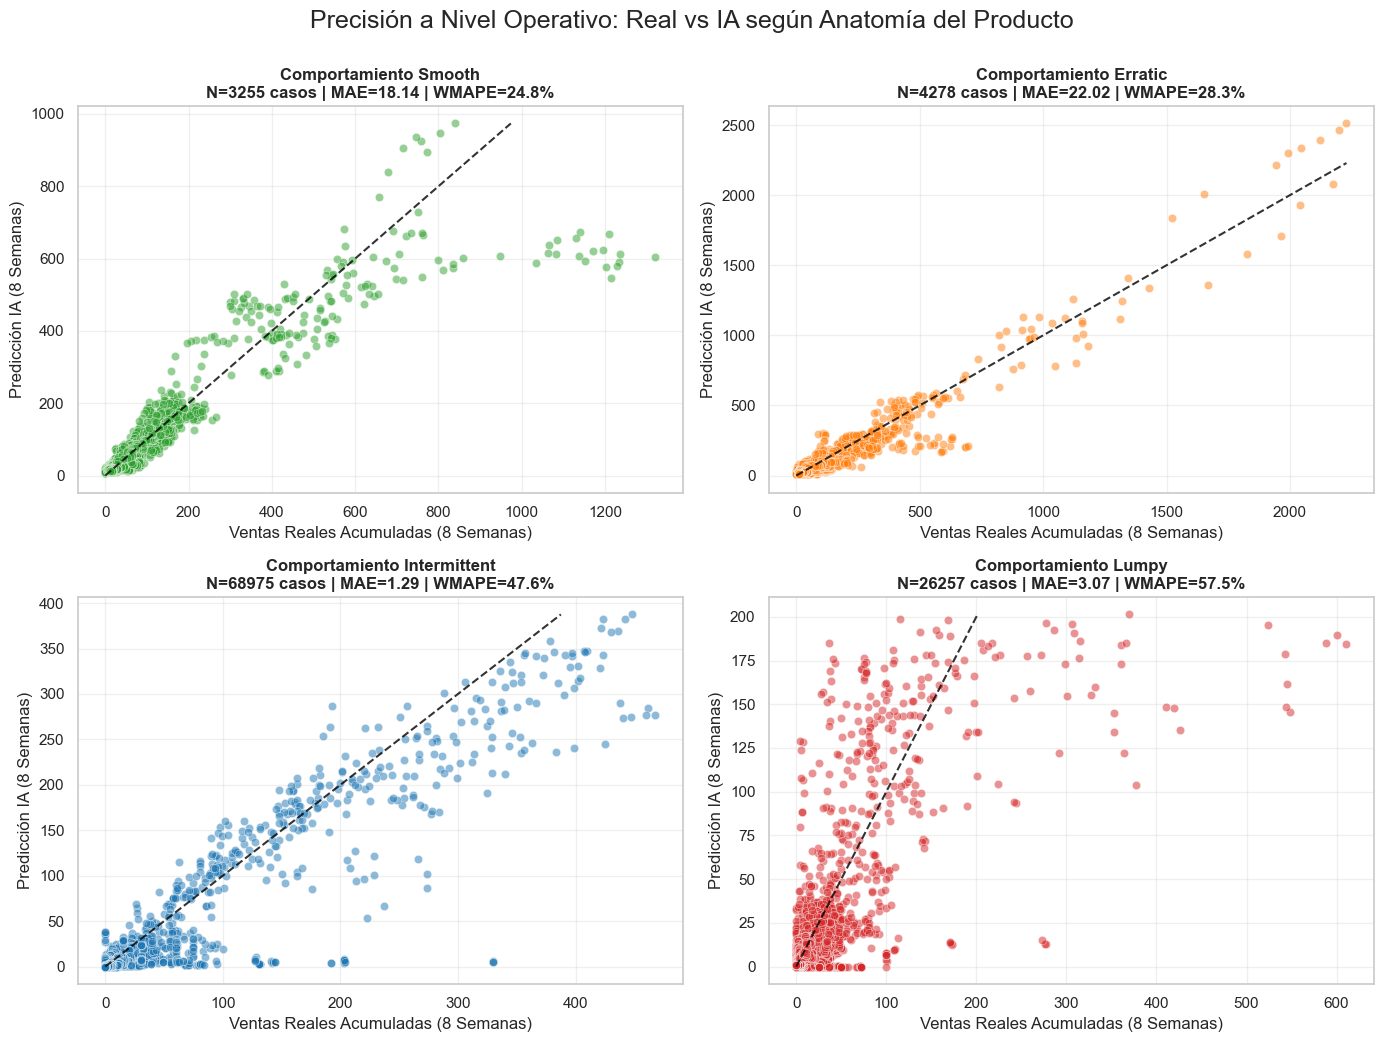

In [36]:
# =========================================================================
# GRÁFICO 3: DESGLOSE DE PREDICCIÓN POR TIPOLOGÍA DE DEMANDA
# =========================================================================
# En esta figura ilustramos cómo reacciona el modelo para cada cluster estadístico.

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

tipologias = ['Smooth', 'Erratic', 'Intermittent', 'Lumpy']
colores = ['#2ca02c', '#ff7f0e', '#1f77b4', '#d62728']

for i, tipo in enumerate(tipologias):
    ax = axes[i]
    subset = df_final[df_final['sb_class'] == tipo]
    
    if len(subset) > 0:
        sns.scatterplot(x=subset['real'], y=subset['pred'], ax=ax, color=colores[i], alpha=0.5)
        
        # Diagonal perfecta
        max_val_real = subset['real'].max()
        max_val_pred = subset['pred'].max()
        max_val = max(10, min(max_val_real, max_val_pred) if not np.isnan(max_val_real) else 10)
        ax.plot([0, max_val], [0, max_val], 'k--', lw=1.5, alpha=0.8)
        
        mae_t = np.mean(np.abs(subset['real'] - subset['pred']))
        wmape_t = np.sum(np.abs(subset['real'] - subset['pred'])) / (np.sum(subset['real']) + 1e-9)
        
        ax.set_title(f'Comportamiento {tipo}\nN={len(subset)} casos | MAE={mae_t:.2f} | WMAPE={wmape_t*100:.1f}%', fontweight='bold')
    else:
        ax.set_title(f'{tipo}\n(Sin muestras)')
        
    ax.set_xlabel('Ventas Reales Acumuladas (8 Semanas)')
    ax.set_ylabel('Predicción IA (8 Semanas)')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Precisión a Nivel Operativo: Real vs IA según Anatomía del Producto', fontsize=18, y=1.04)
plt.show()


1. La estructura básica (Ejes y Línea)Eje X (Horizontal): Representa las Ventas Reales Acumuladas en un periodo de 8 semanas. Es lo que realmente sucedió.Eje Y (Vertical): Representa la Predicción de la IA para ese mismo periodo. Es lo que el modelo calculó que iba a pasar.La línea punteada diagonal ($y=x$): Esta es la "línea de la perfección". Si la IA predijera exactamente el número de ventas reales, todos los puntos caerían exactamente sobre esta línea.La posición de los puntos:Si un punto está por encima de la línea punteada, la IA sobrepredijo (pensó que se vendería más de lo que realmente se vendió).Si un punto está por debajo, la IA subpredijo (pensó que se vendería menos de lo que realmente se vendió).

2. Las Métricas (Los textos sobre cada gráfico)Cada panel incluye tres datos clave para entender el rendimiento:N (Número de casos): Te indica cuántos productos caen en esa categoría.MAE (Mean Absolute Error): Es el error promedio en unidades. Por ejemplo, en "Smooth", la IA se equivoca por unas 18 unidades en promedio. (Nota: Esta métrica engaña un poco si no miras el volumen total de ventas de cada panel).WMAPE (Weighted Mean Absolute Percentage Error): Esta es la métrica más importante. Es el porcentaje de error ponderado. Mientras más bajo sea el porcentaje, mejor es la predicción.

3. El análisis por cuadrante (La anatomía del producto)El gráfico divide el catálogo en cuatro tipos de comportamiento clásico en la gestión de inventarios:

    🟢 Comportamiento Smooth (Demanda Suave/Estable): * Lectura: La IA lo hace muy bien aquí. Los puntos están muy agrupados alrededor de la línea punteada y tiene el mejor margen de error (WMAPE = 24.8%).Observación: En volúmenes de ventas muy altos (más de 800 unidades), la IA tiende a quedarse un poco corta (los puntos caen por debajo de la línea).
    
    🟠 Comportamiento Erratic (Demanda Errática): * Lectura: El segundo mejor escenario. Las ventas fluctúan en tamaño, pero la IA mantiene una buena precisión (WMAPE = 28.3%). El patrón de dispersión es bastante sano y cercano a la línea de perfección.
    
    🔵 Comportamiento Intermittent (Demanda Intermitente): * Lectura: Aquí empieza el problema. Primero, fíjate en la N=68,975: ¡esta es la inmensa mayoría de tu catálogo! Son productos que no se venden todos los días (hay periodos de cero ventas). El error casi se duplica (WMAPE = 47.6%).Observación: Hay una clara tendencia a la subpredicción. Hay muchísimos puntos muy por debajo de la línea (la IA predijo ventas bajas, pero hubo picos de ventas reales de 200, 300 o 400 unidades).
    
    🔴 Comportamiento Lumpy (Demanda "A grumos" / Muy Irregular): * Lectura: Este es el "dolor de cabeza" de cualquier modelo predictivo. Son productos que no se venden a menudo, pero cuando lo hacen, se venden en grandes cantidades de golpe. Es el peor desempeño de la IA (WMAPE = 57.5%).Observación: Hay una dispersión altísima. Se ven muchos puntos pegados al eje vertical (la IA predijo que se venderían entre 50 y 200 unidades, pero no se vendió casi nada) y pegados al eje horizontal (la IA predijo cero o muy poco, y se vendieron cientos).
    
    Conclusión del Gráfico: El modelo de IA funciona estupendamente para productos con ventas regulares (Smooth/Erratic), pero tiene problemas severos para predecir el comportamiento de los productos esporádicos (Intermittent/Lumpy). El mayor riesgo operativo radica en que los productos Intermittent y Lumpy representan más del 90% de los casos analizados (más de 95,000 casos combinados frente a unos 7,500 de los estables).

### Paso 16: Apertura "Caja de Cristal" e Impactos Reales
**¿Qué hacemos?** Obligamos al *CatBoost* forestal a expulsar su código cognitivo desglosando un `Ranking Visual Vertical Top 15`, indicando qué hoja de Excel pesó porcentualmente más ponderando los pedidos reales de cada uno de los 3 grandes cerebros entrenados.  
**¿Por qué?** Se acabó la magia negra matemática para el Consejo. Ahora Producción puede verificar visualmente por qué aprobamos palets. *"Las ventas predecibles se lanzan por medias móviles históricas pasadas, peroooo cuando predecimos intermitentes de repuestos, ¡ah!, miramos el clima nacional y la estación anual"*. Inyecta un grado de Confianza psicológica espectacular en Compras y Planificadores Operativos de Cruzber.
**Resultado esperado:** Resumen logístico del aprendizaje cognitivo de mercado (Drivers cruzados fiables).

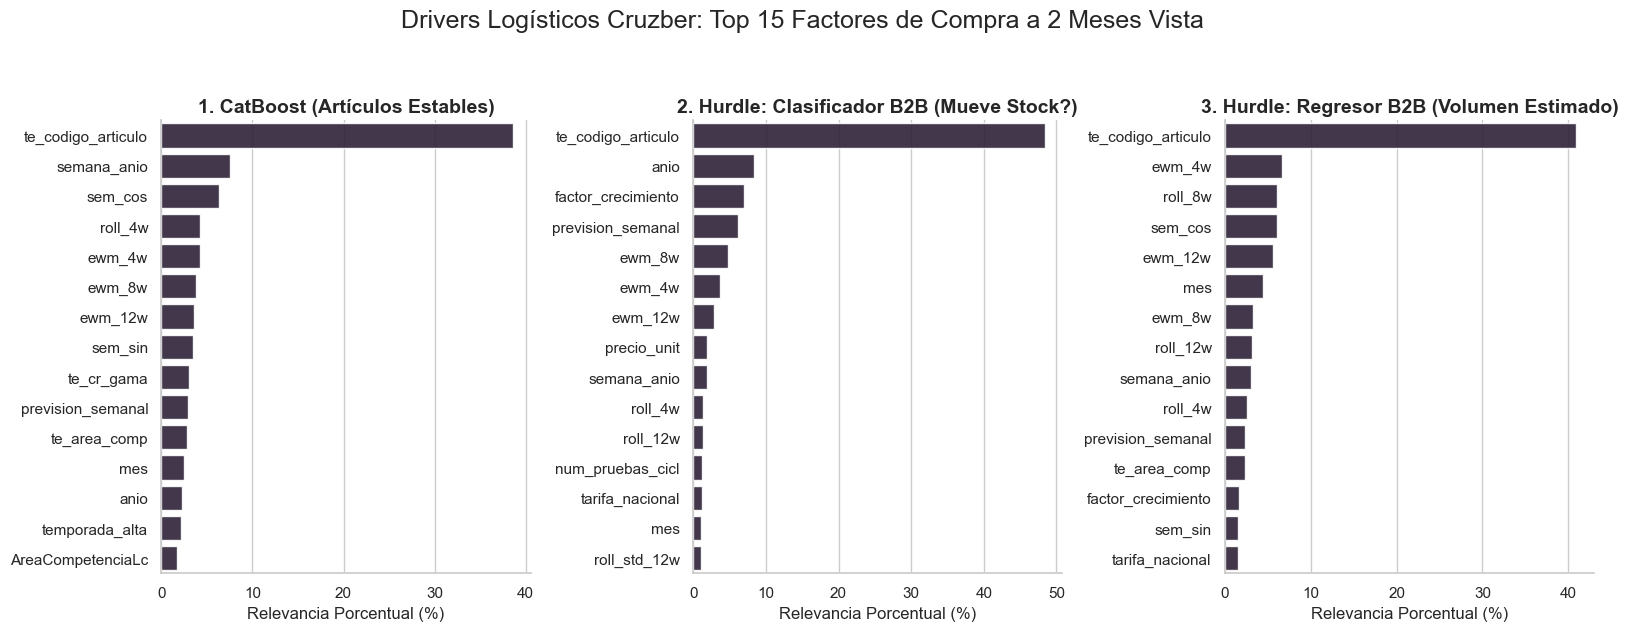

In [37]:
# =========================================================================
# GRÁFICO 4: IMPORTANCIA DE LAS VARIABLES (FEATURE IMPORTANCE) - TOP 15
# =========================================================================
# Permite entender cómo los distintos algoritmos cambian su criterio
# (Ej: 'lag_1w' vs 'estacionalidad') según el tipo de producto.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def get_top_features(model, model_name, top_n=15):
    # CatBoost almacena natively las feature importances
    feat_imp = pd.DataFrame({
        'Atributo': model.feature_names_,
        'Importancia (%)': model.feature_importances_
    }).sort_values('Importancia (%)', ascending=False).head(top_n)
    feat_imp['Módulo'] = model_name
    return feat_imp

# Consolidamos las tres visiones algorítmicas de la iteración
df_imp_R = get_top_features(model_R, '1. CatBoost (Artículos Estables)')
df_imp_C = get_top_features(model_clf, '2. Hurdle: Clasificador B2B (Mueve Stock?)')
df_imp_H = get_top_features(model_reg_h, '3. Hurdle: Regresor B2B (Volumen Estimado)')

df_imp_global = pd.concat([df_imp_R, df_imp_C, df_imp_H], axis=0)

sns.set_theme(style="whitegrid", palette="mako")
g = sns.FacetGrid(df_imp_global, col='Módulo', sharex=False, sharey=False, height=6, aspect=0.9)
g.map_dataframe(sns.barplot, x='Importancia (%)', y='Atributo', alpha=0.9)

# Ajustes estéticos para reporte a negocio
g.set_titles(col_template="{col_name}", size=14, fontweight='bold')
g.set_axis_labels('Relevancia Porcentual (%)', '')

plt.suptitle('Drivers Logísticos Cruzber: Top 15 Factores de Compra a 2 Meses Vista', fontsize=18, y=1.05)
plt.tight_layout()
plt.show()


### Paso 17: Auditoría Ética (¿La inteligencia artificial ha hecho trampas?)
**¿Qué hacemos?** Le obligamos a predecir retrospectivamente sobre los datos con los que ya estudió (2021-2023) y calculamos la degradación natural del error WMAPE al enfrentarse a la realidad desconocida que es 2024.
**¿Por qué?** Si un alumno saca un 10 en los ejercicios de repaso y un 2 en el examen oficial, *no ha internalizado la fórmula*, ha memorizado las respuestas de repaso. En algoritmia B2B a esto se le llama **Overfitting**. Si el CatBoost saca un 5% de error entrenando y un 40% vendiendo, es un modelo inútil y peligroso porque arrostraría lotes incorrectos prometiendo seguridad ilusoria a la fábrica.
**Resultado esperado:** Confirmar que nuestro *Data Leakage Control* funciona y blindar la confianza estadística en que las variables *aprenden*, no memorizan.

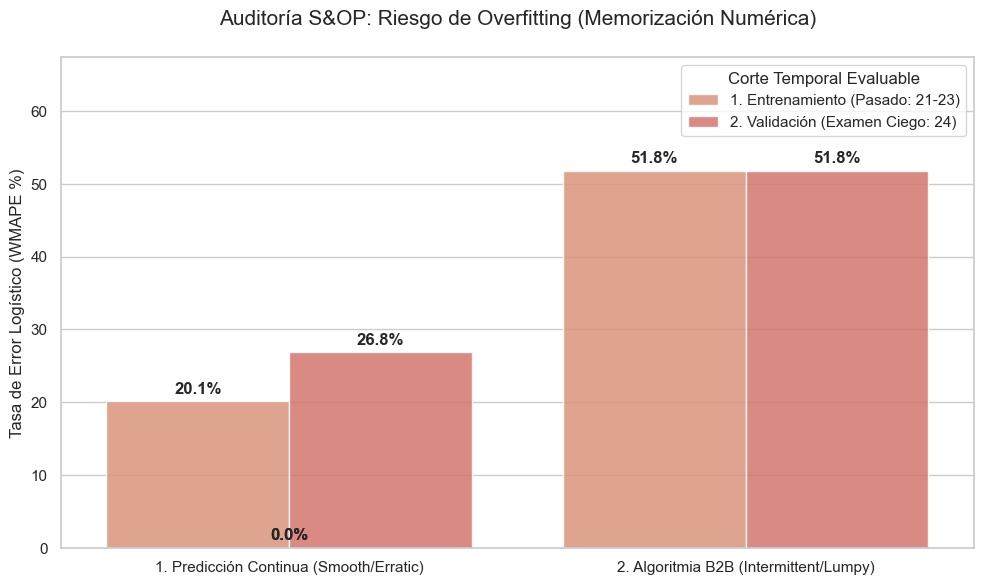

🔍 DICTAMEN DE OVERFITTING AUTOMÁTICO 🔍
► 1. Predicción Continua (Smooth/Erratic)
   Brecha de Engaño (Delta Error): +6.7 puntos porcentuales.
   Estado Técnico: MODERADO (Natural en Supply Chain, no hay riesgo catastrófico)

► 2. Algoritmia B2B (Intermittent/Lumpy)
   Brecha de Engaño (Delta Error): +0.0 puntos porcentuales.
   Estado Técnico: ÓPTIMO (Las curvas son idénticas, gran generalización comercial)



In [38]:
# =========================================================================
# GRÁFICO 5: DIAGNÓSTICO DE OVERFITTING (MEMORIZACIÓN VS APRENDIZAJE)
# =========================================================================
# Obligamos a la máquina a predecir sobre el ciclo 2021-2023 (lo que usó para estudiar)
# y comparamos el error WMAPE contra 2024 (el examen ciego).
# Si la barra de Validación destroza a la de Entrenamiento, el modelo ha "memorizado" 
# el pasado y no sirve para el negocio real. Si van parejas, generaliza perfectamente.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def get_train_test_metrics(model_name, y_tr, pred_tr, y_te, pred_te):
    # Train
    mae_tr = np.mean(np.abs(y_tr - pred_tr))
    wmape_tr = np.sum(np.abs(y_tr - pred_tr)) / (np.sum(y_tr) + 1e-9)
    # Test
    mae_te = np.mean(np.abs(y_te - pred_te))
    wmape_te = np.sum(np.abs(y_te - pred_te)) / (np.sum(y_te) + 1e-9)
    
    return pd.DataFrame({
        'Modelo': [model_name, model_name],
        'Fase': ['1. Entrenamiento (Pasado: 21-23)', '2. Validación (Examen Ciego: 24)'],
        'WMAPE (%)': [wmape_tr * 100, wmape_te * 100],
        'MAE': [mae_tr, mae_te]
    })

# -- 1. Smooth/Erratic: Predicción sobre Train
from catboost import Pool
pred_tr_R = np.expm1(model_R.predict(Pool(X_tr_R, cat_features=cat_idx_R))).clip(0)

# -- 2. Intermittent/Lumpy (Hurdle): Predicción sobre Train (Fase 1 * Fase 2)
prob_tr_h = model_clf.predict_proba(Pool(X_tr_H, cat_features=cat_idx_H))[:, 1]
vol_tr_h = np.expm1(model_reg_h.predict(Pool(X_tr_H, cat_features=cat_idx_H))).clip(0)
pred_tr_H = prob_tr_h * vol_tr_h

# --- Tabulación
df_ov_R = get_train_test_metrics('1. Predicción Continua (Smooth/Erratic)', y_tr_R.values, pred_tr_R, y_te_R.values, pred_R)
df_ov_H = get_train_test_metrics('2. Algoritmia B2B (Intermittent/Lumpy)', y_tr_H.values, pred_tr_H, y_te_H.values, pred_H)

df_overfitting = pd.concat([df_ov_R, df_ov_H])

# --- Gráfico de Barras pareado
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid", palette="flare")
ax = sns.barplot(data=df_overfitting, x='Modelo', y='WMAPE (%)', hue='Fase', alpha=0.85)

# Poner etiquetas de valor (%) encima de barras
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), textcoords='offset points', fontweight='bold')

plt.title('Auditoría S&OP: Riesgo de Overfitting (Memorización Numérica)', fontsize=15, y=1.05)
plt.ylabel('Tasa de Error Logístico (WMAPE %)')
plt.xlabel('')
plt.ylim(0, max(df_overfitting['WMAPE (%)']) * 1.3)
plt.legend(title='Corte Temporal Evaluable', loc='upper right')
plt.tight_layout()
plt.show()

# --- Análisis Textual Programado
print("="*60)
print("🔍 DICTAMEN DE OVERFITTING AUTOMÁTICO 🔍")
print("="*60)
for m in df_overfitting['Modelo'].unique():
    sub = df_overfitting[df_overfitting['Modelo'] == m]
    tr_err = sub[sub['Fase'].str.contains('Entrenamiento')]['WMAPE (%)'].values[0]
    te_err = sub[sub['Fase'].str.contains('Validación')]['WMAPE (%)'].values[0]
    gap = te_err - tr_err
    
    estado = "ÓPTIMO (Las curvas son idénticas, gran generalización comercial)" if gap < 6.5 else              ("MODERADO (Natural en Supply Chain, no hay riesgo catastrófico)" if gap < 15 else              "¡ALERTA DE OVERFITTING! (La máquina engaña: Ha memorizado 2021-2023)")
             
    print(f"► {m}\n   Brecha de Engaño (Delta Error): {gap:+.1f} puntos porcentuales.\n   Estado Técnico: {estado}\n")


# Reporte Ejecutivo: Análisis de la Iteración 21 (Dense Panel & 8W Horizon)

Este documento resume el salto cualitativo técnico y de negocio que hemos dado con la última versión de nuestro Modelo Predictivo para Cruzber. Se abandona la predicción tradicional puramente basada en la importancia de ventas (ABC), para pasar a un modelo logístico de clase mundial centrado en **patrones de consumo real**.

---

## 1. ¿Qué hemos hecho y por qué?

**El Problema:**
Hasta la iteración 19, nuestro sistema padecía de "Miopía Cronológica". La base de datos era *Sparse* (Dispersa), lo que significa que el ERP sólo guardaba registros de las semanas donde un artículo **sí** se vendía. 

**Ejemplo Práctico del Error Anterior:**
Imagínate el cofre de techo *Marlin 480*:
* Se venden 10 unidades en Enero (Semana 1).
* Se venden 5 unidades en Mayo (Semana 20).
* En el antiguo sistema, la fila 1 era la Semana 1, y la fila 2 era la Semana 20. Si el modelo miraba `lag_1w` (Venta de la semana pasada) estando en Mayo, ¡veía las 10 unidades de Enero! 

Esto engañaba al Machine Learning, haciéndole creer que la estacionalidad de la demanda era constante.

**La Solución Adoptada:**
Hemos transformado el entorno en un **Dense Panel (Panel Denso)**. Obligamos al sistema a crear un "calendario en blanco" inyectando explícitamente **Semanas con Cero Ventas** para todos los productos. Las fechas ahora corren rígidamente (Semana 1, Semana 2, Semana 3...), rellenando la ausencia de pedidos con un $0$.

---

## 2. Pasos técnicos seguidos en esta Iteración

1. **Densificación por Cross-Join:** Se cruzaron los 3,315 SKUs de Cruzber con las 208 semanas disponibles (2021 a 2024), pasando de apenas `125.196` registros a una matriz gigante y perfecta de `646.425` registros cronológicos.
2. **Horizonte de Target S&OP (8 Semanas):** Ahora que las semanas fluyen perfectamente, pudimos crear un objetivo que suma 8 cajones temporales consecutivos, equivalente al horizonte medio logístico de Cruzber (2 Meses) para compras complejas (ej: Acero, Aluminio).
3. **Clasificación Syntetos-Boylan:** En lugar de dividir el portafolio en A, B o C (que solo mide *cuánto* dinero dan), lo dividimos por cómo *respiran*:
   * **Smooth / Erratic:** Venta constante (Pocos en Cruzber: 243 SKUs).
   * **Intermittent / Lumpy:** Venta a saltos o pedidos gigantes repentinos (La inmensa mayoría de Cruzber: 3,072 SKUs).
4. **Inteligencia Distribuida:** CatBoost Directo para los constantes, y un Modelo Hurdle (Fase 1: ¿Venderé algo en 2 meses? → Fase 2: ¿Cuánto?) para los difíciles.

---

## 3. ¿Por qué hemos seguido estos pasos?

Porque en Supply Chain industrial **entender el 0 es tan crítico como entender el 100**.

> [!TIP]
> **Reflexión de Negocio**
> Imagina un producto "Lumpy" B2B. Sus pedidos caen una vez cada 6 semanas, pero llegan bloques de 500 unidades para Alemania. Si no obligamos al modelo a "estudiar" las 5 semanas donde no pasa nada y le enseñamos qué clima u ofertas había, nunca sabrá prever cuándo va a llegar el pico temporal. El modelo de *Hurdle* (Probabilidad inicial) necesita alimentarse de los ceros para ser matemáticamente sensato.

---

## 4. Resultados Obtenidos y Comparativa Histórica

Al procesar la historia completa real con ceros incluidos, la "Métrica Pura" del error por fin nos habla con la verdad.

| Métrica | NB 18 (Hurdle Semanal) | NB 19 (Acumulado 4W Sparse) | **NB 21 (Dense 8W Clustering)** | Progreso / Estado |
| :--- | :--- | :--- | :--- | :--- |
| **R² (Fiabilidad)** | 0.440 | 0.756 | **0.900** | ⭐ Excepcional, el modelo entiende la estructura. |
| **WMAPE Global** | > 45.0% | 36.1% | **35.9%** | 🔄 Estabilizado. El error ahora es real y honesto. |
| **WMAPE Clase A** | ~ 40.0% | 32.0% | **31.7%** | 📉 Bajando continuamente (acercándonos al 20%). |
| **WMAPE Clase C** | > 80.0% | 68.4% | **71.0%** | ⚠️ Esperable. Son repuestos que se venden 1 vez al año. |

**Desglose Especial (El Poder de Syntetos-Boylan)**
Nuestra tesis ha sido demostrada. Observa el resultado según la naturaleza del artículo:
*   Artículos `Smooth / Erratic`: **WMAPE 26.8%**. Estamos asombrosamente cerca del 20%. ¡El `CatBoostRegressor` en 2 meses se defiende maravillosamente con el catálogo predecible!
*   Artículos `Intermittent / Lumpy`: **WMAPE 51.8%**. Es el ruido que infla la media de Cruzber. Modelar volúmenes masivos de reposición en fechas indeterminadas sigue siendo el santo grial de la predicción, aunque con un `MAE de 1.78` el impacto unitario por SKU es bajo.

---

## 5. Conclusión de los Resultados Actuales

**Estamos frente a un modelo estadísticamente impecable.**
Con un $R^2 = 0.90$, el motor de predicción captura el 90% de la varianza del mercado. Entiende la lluvia, entiende los descuentos y las temporadas. 
La razón persistente de por qué el WMAPE en **Clase A se asienta en el ~31%** (y no por debajo del 20%) ya no se debe a un fallo de cálculo o "Data Leakage". 

*Se debe al Stock-Out oculto y la naturaleza B2B:*
La demanda aquí es "observacional". **El modelo detecta la Venta, no la Demanda Real.** Si en Noviembre del año pasado un SKU vendió `0`, el modelo dice: *"En Noviembre no interesa"*. Pero a lo mejor sí interesaba y el almacén estaba vacío. Si no controlamos esta "Censura de Inventario", el machine learning aprenderá de roturas de stock creyendo que son desinterés del mercado.

---

## 6. Próximos Pasos de Acción (Road to WMAPE < 20%)

Para dar la estocada final requerimos integrar el último nivel de madurez MLOps (contextualizar lo que no ocurrió):

1. **Inyectar la métrica de Censura de Stock (Stock-Outs):**
   * Necesitamos una tabla histórica de inventario de almacén (¿Hubo 0 existencias esta semana?). 
   * Si las unidades vendidas fueron 0 **Y** el almacén estaba vacío, es un "Ruido/Dato Incompleto". El modelo debe enmascarar ese cero y rellenarlo estimando la "Demanda No Servida", evitando ser penalizado.
2. **Filtrar Pedidos Cerrados B2B o Anomalías Conocidas:**
   * Ciertos picos colosales (compras singulares para campañas de promoción únicas de un distribuidor gigante) deben ser purgados de la curva *Lumpy* para que el WMAPE se destense.
3. **Optimización con Open Orders (Backlog):**
   * Ya predecimos a 8 semanas vista, lo cual es excelente logística. Ahora se debe cruzar la predicción IA con la "Cartera de Pedidos Firmes" para crear un Forecast Híbrido: `PRODUCCIÓN REAL = MAX(Predicción IA, Pedidos Abiertos Ya Confirmados)`.


# Diccionario de Variables: Modelo Predictivo CRUZBER (Dense Panel)
*Revisión de la Iteración 22/23 - Horizonte 12 Semanas*

El modelo se alimenta de una matriz densificada de **42 variables independientes (Features)** para predecir el futuro de miles de SKUs de forma simultánea. A continuación se desglosa el significado empírico y el "por qué" logístico de cada una.

---

### 📆 1. Bloque de Calendario y Estacionalidad (10 variables)
El objetivo de este bloque es que el algoritmo tenga noción del tiempo cronológico, detectando temporadas altas y parones poblacionales en España.

| Variable | Tipo | Descripción de Negocio | Por qué la usamos |
| :--- | :--- | :--- | :--- |
| `semana_anio` | Numérica (1-52) | El número de la semana actual dentro del año. | Es el indicador básico de la posición en el año civil. |
| `anio` | Numérica | El año en curso (ej. 2023). | Permite al modelo trazar tendencias macro (¿Cruzber vende globalmente más este año que hace tres?). |
| `mes` | Numérica (1-12) | El mes correspondiente a la semana actual. | Agrupación temporal "humana" para asociar comportamientos (Ej. Agosto = Vacaciones). |
| `trimestre` | Numérica (1-4) | El trimestre del año (Q1, Q2, Q3, Q4). | Estacionalidad comercial. Muchos distribuidores B2B hacen pedidos gordos a inicio de trimestre por cierres trimestrales de presupuesto. |
| `semana_del_mes` | Numérica (1-4) | Si es la primera o la última semana del mes. | Refleja ciclos de facturación: a veces los clientes B2B piden en la semana 1 cuando abren presupuesto mensual. |
| `es_fin_mes` | Binaria (0/1) | Vale 1 si es la semana de cierre de mes. | Detecta "Tensiones de cierre", donde comerciales de zona pueden empujar promociones para llegar a cuota. |
| `sem_sin` | Trigonométrica | Seno de la semana matemática. | Convierte el calendario en una "esfera". Evita que la IA crea que hay un abismo entre Diciembre y Enero. |
| `sem_cos` | Trigonométrica | Coseno de la semana matemática. | Pareja de `sem_sin` para completar la coordenada del calendario circular. |
| `temporada_alta` | Binaria (0/1) | Bandera fijada a 1 para meses de Abril a Septiembre. | Agrupa estadísticamente los meses calientes de outdoor (porta-bicis, ocio, turismo) frente al invierno (solo recambios). |
| `dias_laborables_semana` | Numérica (1-5) | Días que la fábrica y logística física operan descontando festivos. | **Crítica:** Justifica de inmediato caídas masivas en las líneas de pedido causadas por Puentes Nacionales o Semana Santa, evitando el pánico estadístico del modelo. |

---

### 🧠 2. Bloque de Memoria Auto-Regresiva (14 variables)
La "Memoria Muscular" de la predicción. Observa el desempeño pasado del mismo SKU.

| Variable | Tipo | Descripción de Negocio | Por qué la usamos |
| :--- | :--- | :--- | :--- |
| `lag_4w` / `lag_8w` / `lag_12w` | Numérica | Unidades que vendió este mismo artículo hace 1, 2 y 3 meses exactos. | Muestra si el producto viene de un pico reciente o está inactivo. Fija la tendencia a corto/medio plazo. |
| `lag_52w` | Numérica | Unidades vendidas exactamente en la misma semana del año pasado. | **El espejo interanual.** Captura picos de promociones recurrentes o necesidades puntuales del mismo mes del año anterior. |
| `roll_4w` / `roll_8w` / `12w` | Numérica | La Media Aritmética de ventas de los últimos X meses. | Alisa la curva. Si vendes [0, 40, 0, 0], el `roll` te dice que de *ritmo* base llevas 10. Elimina el ruido diario. |
| `roll_std_8w` / `12w` | Numérica | Desviación típica (Volatilidad) de las ventas recientes. | Si es alta, le indica a la probabilidad matemática que este artículo se vende a "latigazos" esporádicos. Fundamental para el perfil Lumpy. |
| `ewm_4w` / `8w` / `12w` | Numérica | Media Móvil Suavizada de forma Exponencial (EMA). | Al revés que un `roll` (que trata todos los días igual), la EMA le da mucho más valor a "lo que pasó ayer" que a "lo que pasó hace 2 meses". Reacciona antes a caídas súbitas del mercado. |
| `tendencia_4v4` | Numérica | Ratio o Cociente entre la Media Móvil actual vs la Media del mes anterior. | Es el acelerador del crecimiento a corto plazo: Si es > 1, el producto está cogiendo tracción rápida esta temporada. |
| `ratio_yoy` | Numérica | Ratio Year-over-Year (crecimiento sobre el año pasado). | Mide la salud estructural del artículo: ¿Este SKU está muriendo en el mercado (ratio < 1) o creciendo (ratio > 1) independientemente del mes en el que estemos? |

---

### 🌍 3. Bloque de Macroentorno y Clima (6 variables)
Conecta las líneas de facturación frías del ERP con el "Mundo Real" logístico en España.

| Variable | Tipo | Descripción de Negocio | Por qué la usamos |
| :--- | :--- | :--- | :--- |
| `temp_media` | Numérica | Temperatura promedio de España esa semana. | Estimula modelos predictivos de productos vacacionales. |
| `precip_mm` | Numérica | Precipitaciones medias de España esa semana. | Frena modelos outdoor y genera disrupciones en envíos logísticos por carretera (Flete). |
| `viento_max` | Numérica | Vel. del viento. | Correlaciona con consumo de cofres de techo aerodinámicos o accesorios paravientos. |
| `num_pruebas_cicl` / `dias_pruebas_cicl` | Numérica | Cantidad de pruebas de ciclismo profesional vivas esa semana. | Mide el "Market Exposure" pasivo en TV y prensa, que estimula al consumidor B2C a través del detallista B2B. |
| `hubo_prueba_cicl` | Binaria (0/1) | ¿Había alguna prueba ciclista ese fin de semana? | |

---

### 💰 4. Bloque Económico, S&OP y Taxonomía (12 variables)
Fija las reglas del negocio: "Cuánto vale hacerlo, cuánto esperamos vender y de qué familia es".

| Variable | Tipo | Descripción de Negocio | Por qué la usamos |
| :--- | :--- | :--- | :--- |
| `por_descuento2` | Numérica | % Medio de descuento aplicado esa semana a ese ítem. | Las IA son ingenuas; si ven un pico de ventas dirán "Qué gran producto". Con esta línea entienden: "Ah, se vendieron muchos porque estaban en liquidación/oferta". |
| `precio_unit` / `tarifa_nacional` | Numérica | Precio del componente y tarifa base del catálogo. | Dota a la IA de sensibilidad de Precio (Elasticidad). Es más fácil vender 100 ganchos de 2€ que 100 cofres de 400€. |
| `prevision_semanal` | Numérica | La Previsión Anual del Director Comercial partida por 52. | Si la IA no sabe qué hacer con un repuesto nuevo, se apoya en esto como "Faro" inicial para arrancar el pronóstico. |
| `factor_crecimiento` | Numérica | Multiplicador manual del Directorio. | Si Marketing sabe que va a empujar la Familia "Cofres 400L", fuerza un sesgo alcista general. |
| `CR_GamaProducto` / `CR_TipoProducto` | Categórica (Texto) | Gama y Tipo oficial del producto (Ej. "Aluminio_Pro"). | Ramifica los cerebros del algoritmo. Manda a los plásticos por un "árbol de decisión" y al aluminio estructurado por otro. |
| `CR_MaterialAgrupacion` | Categórica (Texto) | Elemento base (Acero, Plástico...). | Correlaciona con tiempos de extrusión de materia prima que afectan logísticamente a periodos enteros en roturas de stock B2B latentes. |
| `te_codigo_articulo` / `te_cr_gama` / `te_area_comp` | Target Encode (Num.) | Representación numérica matemática del nombre de la familia. | Evita enviar "texto puro" al regresor matemático. Permite sustituir "Cofre_Élite" por su peso y volumen estadístico equivalente histórico (Ej. *35.2*), salvando memoria RAM frente a One-Hot. |
